# Sparse Graph Baseline for DMF

Notebook n?y train baseline Sparse Graph thu?n PyTorch cho b?i to?n x?p h?ng t?n d?ng doanh nghi?p. M?i d?ng rating l? m?t node doanh nghi?p-th?i ?i?m; c?nh th?a ???c t?o t? kNN theo feature chu?n h?a trong c?ng sector, c?nh th?i gian li?n ti?p theo ticker, v? self-loop. Model d?ng message passing ki?u GraphSAGE/GCN v?i `torch.sparse.mm`, kh?ng ph? thu?c `torch_geometric`.

Output ch?nh v?n l? `gat_val_predictions.csv` v? `gat_test_predictions.csv` ?? notebook DMF/DCS join v?i LSTM theo `row_id`.

## Notebook Contract
- Input canonical tr?n Kaggle: `/kaggle/input/datasets/tailength/corporate-credit-rating/test/{train,val,test}.csv`.
- Output writable: `/kaggle/working/credit_rating_artifacts/`.
- DMF/DCS contract: prediction CSV gi? `row_id`, `ticker`, `rating_date`, true/pred labels, confidence, `prob_0..prob_n`, v? `label_mapping.csv`.
- Graph contract: d?ng sparse row graph, g?m kNN feature edges trong c?ng sector, temporal ticker edges hai chi?u, self-loops, row-normalized edge weights, v? full-batch sparse message passing.
- Class 0 l? l?p thi?u s? c?n theo d?i ri?ng; notebook ch?n checkpoint b?ng score c? `Class0_F2`, d?ng CE-dominant loss, v? calibrate threshold class 0 b?ng validation tr??c khi ??nh gi?/export test.


In [1]:
import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, RobustScaler, label_binarize
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, auc, cohen_kappa_score,
    confusion_matrix, classification_report,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def detect_kaggle_runtime() -> bool:
    if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '').strip():
        return True
    return Path('/kaggle/input').exists() and Path('/kaggle/working').exists()


IN_KAGGLE = detect_kaggle_runtime()


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start


PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(Path.cwd().resolve())
ARTIFACT_DIR = PROJECT_ROOT / 'credit_rating_artifacts'
DMF_ARTIFACT_DIR = ARTIFACT_DIR / 'dmf_gat_lstm'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
DMF_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device)
print('Project root:', PROJECT_ROOT)
print('DMF artifact dir:', DMF_ARTIFACT_DIR)


Device: cpu
Project root: /kaggle/working
DMF artifact dir: /kaggle/working/credit_rating_artifacts/dmf_gat_lstm


In [2]:
# ── Shared two-tier loss, calibration, and probability metrics ──────────────
# Inlined from src/models/losses.py for standalone execution (e.g. Kaggle).
# The benchmark protocol uses plain multiclass negative log-likelihood (NLL).
# The ordinal ablation adds a normalized squared CDF distance (EMD) without
# changing the model output shape or using CORAL/CORN.

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Iterable

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

BENCHMARK_PROTOCOL = "benchmark_ce"
ORDINAL_PROTOCOL = "ordinal_ce_emd"
SUPPORTED_PROTOCOLS = (BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL)
DEFAULT_ORDINAL_LAMBDA = 0.10
DEFAULT_LABEL_ORDER = ("Distressed", "HY", "IG")
_EPS = 1e-12

# Papermill-injectable parameters.
LOSS_PROTOCOL = "benchmark_ce"
ORDINAL_LAMBDA = 0.10
LABEL_SMOOTHING = float(globals().get("LABEL_SMOOTHING", 0.04))
TARGET_ORDERED_LABELS = ["Distressed", "HY", "IG"]


def normalize_protocol(protocol: str) -> str:
    """Validate and normalize a two-tier loss protocol name."""
    normalized = str(protocol).strip().lower()
    if normalized not in SUPPORTED_PROTOCOLS:
        raise ValueError(
            f"Unsupported loss protocol {protocol!r}; expected one of "
            f"{SUPPORTED_PROTOCOLS}."
        )
    return normalized


def _normalize_probabilities(probabilities: Any) -> np.ndarray:
    probs = np.asarray(probabilities, dtype=np.float64)
    if probs.ndim != 2 or probs.shape[1] < 2:
        raise ValueError("probabilities must have shape (n_samples, n_classes>=2)")
    if not np.isfinite(probs).all():
        raise ValueError("probabilities contain NaN or infinite values")
    probs = np.clip(probs, _EPS, None)
    row_sums = probs.sum(axis=1, keepdims=True)
    if np.any(row_sums <= 0.0):
        raise ValueError("each probability row must have a positive sum")
    return probs / row_sums


def _validate_targets(targets: Any, n_samples: int, n_classes: int) -> np.ndarray:
    y_true = np.asarray(targets, dtype=np.int64).reshape(-1)
    if len(y_true) != n_samples:
        raise ValueError("targets length does not match probabilities")
    if np.any((y_true < 0) | (y_true >= n_classes)):
        raise ValueError("targets contain class ids outside the probability columns")
    return y_true


def numpy_nll(probabilities: Any, targets: Any) -> float:
    """Mean multiclass negative log-likelihood from probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    return float(-np.log(probs[np.arange(len(y_true)), y_true]).mean())


def numpy_cdf_emd2(probabilities: Any, targets: Any) -> float:
    """Normalized squared CDF distance for ordered multiclass probabilities."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    predicted_cdf = np.cumsum(probs, axis=1)[:, :-1]
    target_cdf = np.cumsum(target_one_hot, axis=1)[:, :-1]
    return float(np.square(predicted_cdf - target_cdf).mean())


def numpy_objective(
    probabilities: Any,
    targets: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> float:
    """Evaluate the selected two-tier objective from class probabilities."""
    protocol = normalize_protocol(protocol)
    nll = numpy_nll(probabilities, targets)
    if protocol == BENCHMARK_PROTOCOL:
        return nll
    return nll + float(ordinal_lambda) * numpy_cdf_emd2(probabilities, targets)


def benchmark_ce(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Plain multiclass CE used by the primary benchmark."""
    return F.cross_entropy(logits.float(), targets.long(), label_smoothing=LABEL_SMOOTHING)


def cdf_emd2(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Differentiable normalized squared CDF distance from logits."""
    logits = logits.float()
    targets = targets.long()
    probabilities = torch.softmax(logits, dim=1)
    target_one_hot = F.one_hot(
        targets,
        num_classes=probabilities.shape[1],
    ).to(dtype=probabilities.dtype)
    predicted_cdf = probabilities.cumsum(dim=1)[:, :-1]
    target_cdf = target_one_hot.cumsum(dim=1)[:, :-1]
    return (predicted_cdf - target_cdf).square().mean()


def ordinal_ce_emd(
    logits: torch.Tensor,
    targets: torch.Tensor,
    *,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> torch.Tensor:
    """CE plus normalized squared CDF-EMD for the ordinal ablation."""
    return benchmark_ce(logits, targets) + float(ordinal_lambda) * cdf_emd2(
        logits,
        targets,
    )


class TwoTierClassificationLoss(nn.Module):
    """Single loss API shared by all neural notebook baselines."""

    def __init__(
        self,
        protocol: str = BENCHMARK_PROTOCOL,
        ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    ) -> None:
        super().__init__()
        self.protocol = normalize_protocol(protocol)
        self.ordinal_lambda = float(ordinal_lambda)
        if self.ordinal_lambda < 0.0:
            raise ValueError("ordinal_lambda must be non-negative")

    def monitor_loss(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        """Always return comparable plain NLL for curves and reports."""
        return benchmark_ce(logits, targets)

    def loss_parts(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> dict[str, torch.Tensor]:
        nll = benchmark_ce(logits, targets)
        emd = cdf_emd2(logits, targets)
        objective = (
            nll
            if self.protocol == BENCHMARK_PROTOCOL
            else nll + self.ordinal_lambda * emd
        )
        return {
            "objective": objective,
            "nll": nll,
            "cdf_emd2": emd,
            # Compatibility aliases for existing notebook training loops.
            "ce_loss": nll,
            "aux_loss": objective - nll,
        }

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor,
        **_: Any,
    ) -> torch.Tensor:
        return self.loss_parts(logits, targets)["objective"]


def build_loss(
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
) -> TwoTierClassificationLoss:
    """Factory used by notebook import and fallback paths."""
    return TwoTierClassificationLoss(
        protocol=protocol,
        ordinal_lambda=ordinal_lambda,
    )


def apply_temperature(probabilities: Any, temperature: float) -> np.ndarray:
    """Apply scalar temperature scaling to probabilities via log-probabilities."""
    probs = _normalize_probabilities(probabilities)
    temperature = float(temperature)
    if not np.isfinite(temperature) or temperature <= 0.0:
        raise ValueError("temperature must be finite and positive")
    scaled_logits = np.log(probs) / temperature
    scaled_logits -= scaled_logits.max(axis=1, keepdims=True)
    scaled = np.exp(scaled_logits)
    return scaled / scaled.sum(axis=1, keepdims=True)


def fit_temperature(
    probabilities: Any,
    targets: Any,
    *,
    bounds: tuple[float, float] = (0.05, 10.0),
) -> float:
    """Fit one temperature on validation probabilities by minimizing NLL."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    lower, upper = map(float, bounds)
    if not 0.0 < lower < upper:
        raise ValueError("temperature bounds must satisfy 0 < lower < upper")
    result = minimize_scalar(
        lambda value: numpy_nll(apply_temperature(probs, value), y_true),
        bounds=(lower, upper),
        method="bounded",
        options={"xatol": 1e-6},
    )
    if not result.success or not np.isfinite(result.x):
        return 1.0
    return float(np.clip(result.x, lower, upper))


@dataclass(frozen=True)
class TemperatureCalibrationResult:
    """Cross-fitted validation and final test calibration output."""

    validation_probabilities: np.ndarray
    test_probabilities: np.ndarray
    temperature: float
    fold_temperatures: tuple[float, ...]
    n_splits: int


def cross_fit_temperature_scaling(
    validation_probabilities: Any,
    validation_targets: Any,
    test_probabilities: Any,
    *,
    max_splits: int = 5,
    seed: int = 42,
) -> TemperatureCalibrationResult:
    """Cross-fit validation calibration and fit one final validation temperature."""
    val_probs = _normalize_probabilities(validation_probabilities)
    test_probs = _normalize_probabilities(test_probabilities)
    if val_probs.shape[1] != test_probs.shape[1]:
        raise ValueError("validation and test probabilities need equal class counts")
    y_val = _validate_targets(validation_targets, len(val_probs), val_probs.shape[1])

    class_counts = np.bincount(y_val, minlength=val_probs.shape[1])
    positive_counts = class_counts[class_counts > 0]
    n_splits = min(int(max_splits), int(positive_counts.min())) if len(positive_counts) else 0
    calibrated_val = np.empty_like(val_probs)
    fold_temperatures: list[float] = []

    if n_splits >= 2:
        splitter = StratifiedKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=int(seed),
        )
        for fit_idx, holdout_idx in splitter.split(val_probs, y_val):
            temperature = fit_temperature(val_probs[fit_idx], y_val[fit_idx])
            calibrated_val[holdout_idx] = apply_temperature(
                val_probs[holdout_idx],
                temperature,
            )
            fold_temperatures.append(temperature)
    else:
        n_splits = 1
        temperature = fit_temperature(val_probs, y_val)
        calibrated_val[:] = apply_temperature(val_probs, temperature)
        fold_temperatures.append(temperature)

    final_temperature = fit_temperature(val_probs, y_val)
    calibrated_test = apply_temperature(test_probs, final_temperature)
    return TemperatureCalibrationResult(
        validation_probabilities=calibrated_val,
        test_probabilities=calibrated_test,
        temperature=final_temperature,
        fold_temperatures=tuple(fold_temperatures),
        n_splits=n_splits,
    )


def multiclass_brier_score(probabilities: Any, targets: Any) -> float:
    """Mean multiclass Brier score."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    target_one_hot = np.eye(probs.shape[1], dtype=np.float64)[y_true]
    return float(np.square(probs - target_one_hot).sum(axis=1).mean())


def expected_calibration_error(
    probabilities: Any,
    targets: Any,
    *,
    n_bins: int = 15,
) -> float:
    """Top-label expected calibration error."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    predictions = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correctness = predictions == y_true
    edges = np.linspace(0.0, 1.0, int(n_bins) + 1)
    ece = 0.0
    for index in range(int(n_bins)):
        lower, upper = edges[index], edges[index + 1]
        mask = (
            (confidence >= lower) & (confidence < upper)
            if index < int(n_bins) - 1
            else (confidence >= lower) & (confidence <= upper)
        )
        if mask.any():
            ece += float(mask.mean()) * abs(
                float(correctness[mask].mean()) - float(confidence[mask].mean())
            )
    return float(ece)


def probability_report(
    targets: Any,
    probabilities: Any,
    *,
    protocol: str = BENCHMARK_PROTOCOL,
    ordinal_lambda: float = DEFAULT_ORDINAL_LAMBDA,
    last_y: Any | None = None,
) -> dict[str, float | str]:
    """Return the common benchmark/ablation metric contract."""
    probs = _normalize_probabilities(probabilities)
    y_true = _validate_targets(targets, len(probs), probs.shape[1])
    y_pred = probs.argmax(axis=1)
    nll = numpy_nll(probs, y_true)
    emd = numpy_cdf_emd2(probs, y_true)
    normalized_protocol = normalize_protocol(protocol)
    objective = (
        nll
        if normalized_protocol == BENCHMARK_PROTOCOL
        else nll + float(ordinal_lambda) * emd
    )
    y_bin = label_binarize(y_true, classes=np.arange(probs.shape[1]))
    try:
        auc = float(
            roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
        )
    except ValueError:
        auc = float("nan")
    report: dict[str, float | str] = {
        "Protocol": normalized_protocol,
        "NLL": nll,
        "Objective": objective,
        "CDF_EMD2": emd,
        "Brier": multiclass_brier_score(probs, y_true),
        "ECE": expected_calibration_error(probs, y_true),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Macro_F1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "Weighted_F1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "QWK": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "Ordinal_MAE": float(np.abs(y_true - y_pred).mean()),
        "AUC_ROC_OVR_Macro": auc,
        "AUC": auc,
    }
    if last_y is None:
        report["ChgAcc"] = float("nan")
    else:
        previous = np.asarray(last_y, dtype=np.int64).reshape(-1)
        if len(previous) != len(y_true):
            raise ValueError("last_y length does not match targets")
        change_mask = previous != y_true
        report["ChgAcc"] = (
            float(accuracy_score(y_true[change_mask], y_pred[change_mask]))
            if change_mask.any()
            else float("nan")
        )
    return report


def reliability_weights_from_nll(
    validation_targets: Any,
    model_probabilities: Iterable[Any],
) -> np.ndarray:
    """Normalize exp(-validation NLL) reliability weights across models."""
    losses = np.asarray(
        [numpy_nll(probabilities, validation_targets) for probabilities in model_probabilities],
        dtype=np.float64,
    )
    raw = np.exp(-(losses - losses.min()))
    return raw / raw.sum()


# ── Protocol validation ─────────────────────────────────────────────────────
TWO_TIER_LOSS_SOURCE = "inline (losses.py)"
if LOSS_PROTOCOL not in {BENCHMARK_PROTOCOL, ORDINAL_PROTOCOL}:
    raise ValueError(f"LOSS_PROTOCOL must be {BENCHMARK_PROTOCOL!r} or {ORDINAL_PROTOCOL!r}")
print(f"Two-tier loss source={TWO_TIER_LOSS_SOURCE} | protocol={LOSS_PROTOCOL} | ordinal_lambda={ORDINAL_LAMBDA:.2f}")


Two-tier loss source=inline (losses.py) | protocol=benchmark_ce | ordinal_lambda=0.10


In [3]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio', 'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin', 'net_profit_margin', 'asset_turnover',
    'roe', 'roa', 'operating_cashflow_ps', 'free_cashflow_ps'
]
TARGET_COL = 'rating_detail'
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']


def resolve_split_path(default_path, local_fallbacks=None):
    candidates = [Path(default_path)]
    for p in (local_fallbacks or []):
        p_obj = Path(p)
        candidates.append(PROJECT_ROOT / p_obj if not p_obj.is_absolute() else p_obj)
    if IN_KAGGLE:
        kaggle_root = Path('/kaggle/input')
        expanded = []
        for p in candidates:
            expanded.append(p)
            if not p.exists() and kaggle_root.exists():
                expanded.extend(kaggle_root.rglob(p.name))
        candidates = expanded
    seen = set()
    deduped = []
    for p in candidates:
        p = Path(p)
        key = str(p)
        if key not in seen:
            seen.add(key)
            deduped.append(p)
    for p in deduped:
        if p.exists():
            return p
    raise FileNotFoundError(f'Khong tim thay file split: {deduped}')


TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv',
    ['data/processed/test/train.csv'],
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv',
    ['data/processed/test/val.csv'],
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv',
    ['data/processed/test/test.csv'],
)


def load_split(path, split_name):
    frame = pd.read_csv(path)
    frame = frame.copy()
    frame['__split__'] = split_name
    frame['__split_row_index__'] = np.arange(len(frame), dtype=int)
    if 'row_id' not in frame.columns:
        frame['row_id'] = [f'{split_name}_{i:06d}' for i in range(len(frame))]
    else:
        frame['row_id'] = frame['row_id'].astype(str)
    return frame


train_df = load_split(TRAIN_PATH, 'train')
val_df = load_split(VAL_PATH, 'val')
test_df = load_split(TEST_PATH, 'test')
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

split_contract = {
    'train_path': str(TRAIN_PATH),
    'val_path': str(VAL_PATH),
    'test_path': str(TEST_PATH),
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>',
}
print('DMF split contract:', split_contract)

df = df.dropna(subset=[TARGET_COL]).copy()
target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    df[TARGET_COL] = target_as_num.astype(int)
    observed = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(v): i for i, v in enumerate(observed)}
    id_to_raw = {i: int(v) for v, i in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    tgt = df[TARGET_COL].astype(str).str.strip()
    observed = sorted(tgt.unique().tolist())
    ordered = [x for x in TARGET_ORDERED_LABELS if x in observed] if set(observed).issubset(set(TARGET_ORDERED_LABELS)) else observed
    raw_to_id = {v: i for i, v in enumerate(ordered)}
    id_to_raw = {i: v for i, v in raw_to_id.items()}
    df[TARGET_COL] = tgt.map(raw_to_id).astype(int)

n_classes = int(df[TARGET_COL].nunique())
if n_classes != 3:
    raise ValueError(f"Two-tier benchmark requires exactly 3 classes, got {n_classes}.")
id_to_raw = {idx: label for idx, label in enumerate(TARGET_ORDERED_LABELS)}
raw_to_id = {label: idx for idx, label in id_to_raw.items()}
print("Two-tier label contract:", id_to_raw)

label_contract = pd.DataFrame({
    'label_id': list(range(n_classes)),
    'label_name': [str(id_to_raw.get(i, i)) for i in range(n_classes)],
})
label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')

df['rating_date'] = pd.to_datetime(df['rating_date'], errors='coerce', format='mixed')
if 'sector' not in df.columns:
    df['sector'] = 'UNKNOWN'
df['sector'] = df['sector'].fillna('UNKNOWN').astype(str)
if 'ticker' not in df.columns:
    df['ticker'] = 'UNKNOWN'
df['ticker'] = df['ticker'].fillna('UNKNOWN').astype(str)
if 'company_name' not in df.columns:
    df['company_name'] = df['ticker']
df['company_name'] = df['company_name'].fillna(df['ticker']).astype(str)

sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df['sector'])
n_sectors = int(df['sector_id'].nunique())

train_mask_raw = df['__split__'].eq('train')
stats_ref = df.loc[train_mask_raw].copy()
for c in FINANCIAL_FEATURES:
    med = stats_ref[c].median() if stats_ref[c].notna().any() else 0.0
    df[c] = df[c].fillna(float(0.0 if pd.isna(med) else med))
for c in FINANCIAL_FEATURES:
    lo = stats_ref[c].quantile(0.01)
    hi = stats_ref[c].quantile(0.99)
    if pd.notna(lo) and pd.notna(hi):
        df[c] = df[c].clip(float(lo), float(hi))

df = df.sort_values(['ticker', 'rating_date', '__split__', '__split_row_index__']).reset_index(drop=True)
for c in FINANCIAL_FEATURES:
    df[f'{c}_delta'] = df.groupby('ticker')[c].diff().fillna(0.0)
MODEL_FEATURES = FINANCIAL_FEATURES + [f'{c}_delta' for c in FINANCIAL_FEATURES]

scaler = RobustScaler()
scaler.fit(df.loc[df['__split__'].eq('train'), MODEL_FEATURES].values)
df[MODEL_FEATURES] = scaler.transform(df[MODEL_FEATURES].values)

df['last_y'] = df.groupby('ticker')[TARGET_COL].shift(1)
df['last_y'] = df['last_y'].fillna(df[TARGET_COL]).astype(int)

x_all = torch.tensor(df[MODEL_FEATURES].values.astype(np.float32), dtype=torch.float32, device=device)
y_all = torch.tensor(df[TARGET_COL].values.astype(int), dtype=torch.long, device=device)
last_y_all = torch.tensor(df['last_y'].values.astype(int), dtype=torch.long, device=device)
sector_all = torch.tensor(df['sector_id'].values.astype(int), dtype=torch.long, device=device)

train_mask = torch.tensor(df['__split__'].eq('train').values, dtype=torch.bool, device=device)
val_mask = torch.tensor(df['__split__'].eq('val').values, dtype=torch.bool, device=device)
test_mask = torch.tensor(df['__split__'].eq('test').values, dtype=torch.bool, device=device)

train_class_counts = torch.bincount(y_all[train_mask], minlength=n_classes).float()
print('Class weighting/sampling: disabled for the shared benchmark protocol.')

print('Rows train/val/test:', int(train_mask.sum()), int(val_mask.sum()), int(test_mask.sum()))
print('n_classes:', n_classes, '| n_sectors:', n_sectors, '| n_features:', len(MODEL_FEATURES))


DMF split contract: {'train_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv', 'val_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv', 'test_path': '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv', 'train_rows': 8742, 'val_rows': 862, 'test_rows': 1723, 'row_id_rule': 'existing row_id if present, otherwise <split>_<zero_padded_original_split_index>'}
Two-tier label contract: {0: 'Distressed', 1: 'HY', 2: 'IG'}
Class weighting/sampling: disabled for the shared benchmark protocol.
Rows train/val/test: 8742 862 1723
n_classes: 3 | n_sectors: 12 | n_features: 24


In [4]:
CLASS0_LABEL_ID = 0

CLASS0_THRESHOLD_CONFIG = {
    'enabled': False,
    'metric': 'Class0_F2',
    'accuracy_floor_drop': 0.0,
    'min_accuracy_gain': 0.001,
    'threshold_grid': np.round(np.arange(0.05, 0.501, 0.01), 2).tolist(),
}


def predict_with_class0_threshold(proba, class0_threshold=None):
    pred = np.asarray(proba).argmax(axis=1).astype(int)
    if class0_threshold is None:
        return pred
    promote_mask = np.asarray(proba)[:, CLASS0_LABEL_ID] >= float(class0_threshold)
    pred[promote_mask] = CLASS0_LABEL_ID
    return pred


def compute_metrics(y_true, y_pred, proba, n_cls, last_y=None):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    acc = accuracy_score(y_true_arr, y_pred_arr)
    f1m = f1_score(y_true_arr, y_pred_arr, average='macro', zero_division=0)
    f1w = f1_score(y_true_arr, y_pred_arr, average='weighted', zero_division=0)
    prec = precision_score(y_true_arr, y_pred_arr, average='weighted', zero_division=0)
    rec = recall_score(y_true_arr, y_pred_arr, average='weighted', zero_division=0)
    class_prec, class_rec, class_f1, class_support = precision_recall_fscore_support(
        y_true_arr,
        y_pred_arr,
        labels=list(range(n_cls)),
        zero_division=0,
    )
    c0_precision = float(class_prec[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_prec) else float('nan')
    c0_recall = float(class_rec[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_rec) else float('nan')
    c0_f1 = float(class_f1[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_f1) else float('nan')
    c0_support = int(class_support[CLASS0_LABEL_ID]) if CLASS0_LABEL_ID < len(class_support) else 0
    balanced_acc = float(np.mean(class_rec)) if len(class_rec) > 0 else float(acc)
    if c0_precision + c0_recall > 0:
        c0_f2 = float(5.0 * c0_precision * c0_recall / (4.0 * c0_precision + c0_recall))
    else:
        c0_f2 = 0.0
    qwk = cohen_kappa_score(y_true_arr, y_pred_arr, weights='quadratic')
    try:
        y_bin = label_binarize(y_true_arr, classes=list(range(n_cls)))
        auc_score = roc_auc_score(y_bin, proba, average='macro', multi_class='ovr')
    except Exception:
        auc_score = float('nan')
    ordinal_mae = np.mean(np.abs(y_true_arr - y_pred_arr))
    # ChgAcc: accuracy on samples where label changed vs last known rating.
    if last_y is not None:
        last_y_arr = np.asarray(last_y)
        change_mask = last_y_arr != y_true_arr
        if change_mask.sum() > 0:
            chg_acc = float(accuracy_score(y_true_arr[change_mask], y_pred_arr[change_mask]))
        else:
            chg_acc = float('nan')
    else:
        chg_acc = float('nan')
    return {
        'Accuracy': float(acc),
        'Balanced_Accuracy': balanced_acc,
        'Precision_Weighted': float(prec),
        'Recall_Weighted': float(rec),
        'Macro_F1': float(f1m),
        'Weighted_F1': float(f1w),
        'Class0_Precision': c0_precision,
        'Class0_Recall': c0_recall,
        'Class0_F1': c0_f1,
        'Class0_F2': c0_f2,
        'Class0_Support': c0_support,
        'AUC': float(auc_score),
        'QWK': float(qwk),
        'ChgAcc': chg_acc,
        'Ordinal_MAE': float(ordinal_mae),
    }


def evaluate_logits(logits, mask, class0_threshold=None):
    probs = torch.softmax(logits[mask], dim=1).detach().cpu().numpy()
    y_true = y_all[mask].detach().cpu().numpy()
    y_pred = predict_with_class0_threshold(probs, class0_threshold=class0_threshold)
    last_y_np = last_y_all[mask].detach().cpu().numpy()
    return compute_metrics(y_true, y_pred, probs, n_classes, last_y=last_y_np), y_true, y_pred, probs


def selection_score(metrics):
    chg_acc = 0.0 if np.isnan(metrics['ChgAcc']) else metrics['ChgAcc']
    return (
        0.60 * metrics['Accuracy']
        + 0.15 * metrics['QWK']
        + 0.10 * metrics['Macro_F1']
        + 0.10 * metrics['Class0_F2']
        + 0.05 * chg_acc
        - 0.05 * metrics['Ordinal_MAE']
    )


def calibrate_class0_threshold(y_true, proba, last_y=None, config=None):
    config = config or CLASS0_THRESHOLD_CONFIG
    baseline_pred = predict_with_class0_threshold(proba, class0_threshold=None)
    baseline_metrics = compute_metrics(y_true, baseline_pred, proba, n_classes, last_y=last_y)
    rows = [{'class0_threshold': np.nan, 'candidate': 'raw_argmax', **baseline_metrics}]
    for threshold in config['threshold_grid']:
        pred = predict_with_class0_threshold(proba, class0_threshold=threshold)
        metrics = compute_metrics(y_true, pred, proba, n_classes, last_y=last_y)
        rows.append({'class0_threshold': float(threshold), 'candidate': 'class0_threshold', **metrics})
    sweep_df = pd.DataFrame(rows)
    threshold_accuracy_floor = (
        baseline_metrics['Accuracy']
        + float(config.get('min_accuracy_gain', 0.0))
        - float(config.get('accuracy_floor_drop', 0.0))
    )
    raw_candidate = sweep_df['candidate'].eq('raw_argmax')
    threshold_candidate = sweep_df['candidate'].eq('class0_threshold') & (sweep_df['Accuracy'] >= threshold_accuracy_floor)
    candidates = sweep_df[raw_candidate | threshold_candidate].copy()
    if candidates.empty:
        candidates = sweep_df[raw_candidate].copy()
    sort_cols = [config.get('metric', 'Class0_F2'), 'Accuracy', 'Macro_F1', 'QWK']
    best_row = candidates.sort_values(sort_cols, ascending=False).iloc[0]
    best_threshold = None if pd.isna(best_row['class0_threshold']) else float(best_row['class0_threshold'])
    return best_threshold, sweep_df, baseline_metrics, best_row.to_dict()


In [5]:
# Sparse row-graph configuration.
# Node la moi dong rating; edge la quan he thua giua cac dong doanh nghiep-thoi diem.
# Edge khong dung label: kNN theo financial features trong cung sector + temporal ticker edges + self-loops.

LAST_Y_EMB_DIM = 8
SECTOR_EMB_DIM = 8
SPARSE_GRAPH_HIDDEN = 72
SPARSE_GRAPH_LAYERS = 2
SPARSE_GRAPH_KNN_K = 12
SPARSE_GRAPH_MIN_SIMILARITY = 0.05
SPARSE_GRAPH_TEMPORAL_WEIGHT = 1.25
SPARSE_GRAPH_SELF_LOOP_WEIGHT = 1.0
PERSISTENCE_PRIOR_SCALE = 1.25


def _add_sparse_edge(edge_store, dst, src, weight, edge_type):
    key = (int(dst), int(src))
    payload = edge_store.setdefault(key, {'raw_weight': 0.0, 'edge_types': set()})
    payload['raw_weight'] = max(float(payload['raw_weight']), float(weight))
    payload['edge_types'].add(str(edge_type))


def build_sparse_credit_graph(frame, feature_cols, knn_k=12, min_similarity=0.05):
    frame = frame.reset_index(drop=True).copy()
    x_np = frame[feature_cols].to_numpy(dtype=np.float32)
    n_nodes = len(frame)
    edge_store = {}

    for node_idx in range(n_nodes):
        _add_sparse_edge(
            edge_store,
            node_idx,
            node_idx,
            SPARSE_GRAPH_SELF_LOOP_WEIGHT,
            'self_loop',
        )

    for _, sector_index in frame.groupby('sector_id', sort=False).groups.items():
        sector_nodes = np.asarray(list(sector_index), dtype=int)
        if sector_nodes.size <= 1:
            continue
        n_neighbors = min(int(knn_k) + 1, int(sector_nodes.size))
        nn_index = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine', algorithm='brute')
        sector_features = x_np[sector_nodes]
        nn_index.fit(sector_features)
        distances, neighbors = nn_index.kneighbors(sector_features, return_distance=True)
        for local_dst, (dist_row, neigh_row) in enumerate(zip(distances, neighbors)):
            dst = int(sector_nodes[local_dst])
            for distance, local_src in zip(dist_row[1:], neigh_row[1:]):
                src = int(sector_nodes[int(local_src)])
                similarity = 1.0 - float(distance)
                weight = max(float(min_similarity), similarity)
                _add_sparse_edge(edge_store, dst, src, weight, 'sector_feature_knn')
                _add_sparse_edge(edge_store, src, dst, weight, 'sector_feature_knn')

    temporal_sort_cols = ['rating_date', '__split__', '__split_row_index__']
    for _, ticker_rows in frame.groupby('ticker', sort=False):
        ordered = ticker_rows.sort_values(temporal_sort_cols, kind='mergesort')
        row_indices = ordered.index.to_numpy(dtype=int)
        if row_indices.size <= 1:
            continue
        for prev_idx, next_idx in zip(row_indices[:-1], row_indices[1:]):
            _add_sparse_edge(edge_store, next_idx, prev_idx, SPARSE_GRAPH_TEMPORAL_WEIGHT, 'ticker_temporal_prev')
            _add_sparse_edge(edge_store, prev_idx, next_idx, SPARSE_GRAPH_TEMPORAL_WEIGHT, 'ticker_temporal_next')

    rows = []
    for (dst, src), payload in edge_store.items():
        rows.append({
            'dst': int(dst),
            'src': int(src),
            'dst_row_id': str(frame.loc[dst, 'row_id']),
            'src_row_id': str(frame.loc[src, 'row_id']),
            'dst_split': str(frame.loc[dst, '__split__']),
            'src_split': str(frame.loc[src, '__split__']),
            'dst_ticker': str(frame.loc[dst, 'ticker']),
            'src_ticker': str(frame.loc[src, 'ticker']),
            'edge_type': '+'.join(sorted(payload['edge_types'])),
            'raw_weight': float(payload['raw_weight']),
        })
    edge_df = pd.DataFrame(rows)
    edge_df = edge_df.sort_values(['dst', 'src']).reset_index(drop=True)

    dst = edge_df['dst'].to_numpy(dtype=np.int64)
    src = edge_df['src'].to_numpy(dtype=np.int64)
    raw_weight = edge_df['raw_weight'].to_numpy(dtype=np.float32)
    row_sum = np.bincount(dst, weights=raw_weight, minlength=n_nodes).astype(np.float32)
    norm_weight = raw_weight / np.maximum(row_sum[dst], 1e-12)
    edge_df['norm_weight'] = norm_weight.astype(float)

    edge_index = torch.tensor(np.vstack([dst, src]), dtype=torch.long, device=device)
    edge_weight = torch.tensor(norm_weight, dtype=torch.float32, device=device)
    return edge_index, edge_weight, edge_df


edge_index, edge_weight, edge_df = build_sparse_credit_graph(
    df,
    MODEL_FEATURES,
    knn_k=SPARSE_GRAPH_KNN_K,
    min_similarity=SPARSE_GRAPH_MIN_SIMILARITY,
)

sparse_graph_contract = {
    'baseline': 'Sparse row graph / pure PyTorch GraphSAGE-style message passing',
    'node_unit': 'one rating row/company observation',
    'node_count': int(len(df)),
    'edge_count': int(edge_index.size(1)),
    'edge_sources': {
        'sector_feature_knn': int(edge_df['edge_type'].str.contains('sector_feature_knn').sum()),
        'ticker_temporal': int(edge_df['edge_type'].str.contains('ticker_temporal').sum()),
        'self_loop': int(edge_df['edge_type'].str.contains('self_loop').sum()),
    },
    'knn_scope': 'within sector, features only, no target labels',
    'knn_k': SPARSE_GRAPH_KNN_K,
    'min_similarity_weight': SPARSE_GRAPH_MIN_SIMILARITY,
    'temporal_weight': SPARSE_GRAPH_TEMPORAL_WEIGHT,
    'normalization': 'row-normalized incoming weights: adj[dst, src]',
    'message_passing': 'torch.sparse.mm(adj, node_embeddings)',
    'hidden_dim': SPARSE_GRAPH_HIDDEN,
    'num_layers': SPARSE_GRAPH_LAYERS,
    'persistence_prior_scale': PERSISTENCE_PRIOR_SCALE,
}
print('Sparse graph contract:', sparse_graph_contract)
print('Sparse graph edge sample:')
display(edge_df.head(10))


Sparse graph contract: {'baseline': 'Sparse row graph / pure PyTorch GraphSAGE-style message passing', 'node_unit': 'one rating row/company observation', 'node_count': 11327, 'edge_count': 217801, 'edge_sources': {'sector_feature_knn': 195896, 'ticker_temporal': 20280, 'self_loop': 11327}, 'knn_scope': 'within sector, features only, no target labels', 'knn_k': 12, 'min_similarity_weight': 0.05, 'temporal_weight': 1.25, 'normalization': 'row-normalized incoming weights: adj[dst, src]', 'message_passing': 'torch.sparse.mm(adj, node_embeddings)', 'hidden_dim': 72, 'num_layers': 2, 'persistence_prior_scale': 1.25}
Sparse graph edge sample:


,dst,src,dst_row_id,src_row_id,dst_split,src_split,dst_ticker,src_ticker,edge_type,raw_weight,norm_weight
0,0,0,val_000058,val_000058,val,val,AA,AA,self_loop,1.000000,0.101309
1,0,605,val_000058,train_008116,val,train,AA,AUY,sector_feature_knn,0.681088,0.069000
2,0,780,val_000058,test_000288,val,test,AA,BAK,sector_feature_knn,0.900634,0.091242
3,0,1369,val_000058,train_003892,val,train,AA,CBT,sector_feature_knn,0.856260,0.086747
4,0,1370,val_000058,val_000230,val,val,AA,CBT,sector_feature_knn,0.856260,0.086747
5,0,1371,val_000058,train_002507,val,train,AA,CBT,sector_feature_knn,0.856260,0.086747
6,0,3227,val_000058,train_008231,val,train,AA,FOE,sector_feature_knn,0.579332,0.058692
7,0,4380,val_000058,train_001710,val,train,AA,KRO,sector_feature_knn,0.640488,0.064887
8,0,4381,val_000058,train_004882,val,train,AA,KRO,sector_feature_knn,0.640488,0.064887
9,0,4382,val_000058,train_007385,val,train,AA,KRO,sector_feature_knn,0.640488,0.064887


In [6]:
class SparseGraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.20):
        super().__init__()
        self.self_lin = nn.Linear(in_dim, out_dim, bias=False)
        self.neigh_lin = nn.Linear(in_dim, out_dim, bias=False)
        self.bias = nn.Parameter(torch.zeros(out_dim))
        self.dropout = nn.Dropout(dropout)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.self_lin.weight)
        nn.init.xavier_uniform_(self.neigh_lin.weight)
        nn.init.zeros_(self.bias)

    def forward(self, h, sparse_adj):
        # sparse_adj[dst, src] da row-normalized; sparse.mm gom thong tin lang gieng vao node dst.
        neigh = torch.sparse.mm(sparse_adj, h)
        return self.self_lin(h) + self.neigh_lin(neigh) + self.bias


class SparseCreditGraphBaseline(nn.Module):
    def __init__(
        self,
        n_features,
        n_classes,
        n_sectors,
        n_nodes,
        edge_index,
        edge_weight,
        hidden=96,
        num_layers=3,
        dropout=0.25,
        last_y_emb_dim=8,
        sector_emb_dim=8,
        context_dropout=0.15,
        persistence_prior_scale=0.0,
    ):
        super().__init__()
        self.n_nodes = int(n_nodes)
        self.context_dropout = float(context_dropout)
        self.context_unknown_id = int(n_classes)
        self.persistence_prior_scale = float(persistence_prior_scale)
        self.last_y_emb_dim = int(last_y_emb_dim)
        self.last_y_emb = nn.Embedding(n_classes + 1, last_y_emb_dim)
        self.sector_emb = nn.Embedding(n_sectors, sector_emb_dim)
        in_dim = int(n_features) + int(last_y_emb_dim) + int(sector_emb_dim)
        self.input_norm = nn.LayerNorm(in_dim)
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.layers = nn.ModuleList([
            SparseGraphSAGELayer(hidden, hidden, dropout=dropout)
            for _ in range(int(num_layers))
        ])
        self.norms = nn.ModuleList([nn.LayerNorm(hidden) for _ in range(int(num_layers))])
        self.layer_dropout = nn.Dropout(dropout)
        readout_dim = hidden * (int(num_layers) + 1)
        self.head = nn.Sequential(
            nn.LayerNorm(readout_dim),
            nn.Dropout(dropout),
            nn.Linear(readout_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )
        self.register_buffer('edge_index', edge_index.detach().long().clone())
        self.register_buffer('edge_weight', edge_weight.detach().float().clone())

    def build_sparse_adj(self, edge_index=None, edge_weight=None):
        edge_index = self.edge_index if edge_index is None else edge_index.long()
        edge_weight = self.edge_weight if edge_weight is None else edge_weight.float()
        return torch.sparse_coo_tensor(
            edge_index,
            edge_weight,
            size=(self.n_nodes, self.n_nodes),
            device=edge_weight.device,
        ).coalesce()

    def encode_context(self, x, last_y, sector_id, context_mask_prob=0.0):
        if self.training and context_mask_prob > 0.0:
            mask = torch.rand(last_y.shape, device=last_y.device) < float(context_mask_prob)
            last_y = last_y.masked_fill(mask, self.context_unknown_id)
        last_y_emb = self.last_y_emb(last_y)
        if self.training and self.context_dropout > 0:
            last_y_emb = F.dropout(last_y_emb, p=self.context_dropout, training=True)
        h = torch.cat([x, last_y_emb, self.sector_emb(sector_id)], dim=1)
        h = self.input_norm(h)
        return self.input_proj(h)

    def forward(self, x, last_y, sector_id, edge_index=None, edge_weight=None, return_embeddings=False, context_mask_prob=0.0):
        if x.size(0) != self.n_nodes:
            raise ValueError('SparseCreditGraphBaseline yeu cau full-batch x_all dung so node da build graph.')
        sparse_adj = self.build_sparse_adj(edge_index=edge_index, edge_weight=edge_weight)
        h = self.encode_context(x, last_y, sector_id, context_mask_prob=context_mask_prob)
        states = [h]
        for layer, norm in zip(self.layers, self.norms):
            h_next = F.gelu(layer(h, sparse_adj))
            h = norm(h + h_next)
            h = self.layer_dropout(h)
            states.append(h)
        readout = torch.cat(states, dim=1)
        logits = self.head(readout)
        if self.persistence_prior_scale > 0:
            valid_last_y = last_y.clamp(min=0, max=logits.size(1) - 1)
            prior = torch.zeros_like(logits)
            prior.scatter_(1, valid_last_y.view(-1, 1), self.persistence_prior_scale)
            logits = logits + prior
        if return_embeddings:
            return logits, readout
        return logits


CreditGAT = SparseCreditGraphBaseline





# EDGE_DROPOUT parameter definition
EDGE_DROPOUT = 0.12

def apply_dropedge(edge_index, edge_weight, n_nodes, p=0.12):
    if p <= 0:
        return edge_index, edge_weight

    dst, src = edge_index
    is_self_loop = dst.eq(src)

    keep = is_self_loop | (
        torch.rand(edge_weight.size(0), device=edge_weight.device) > p
    )

    new_edge_index = edge_index[:, keep]
    new_edge_weight = edge_weight[keep]

    new_dst = new_edge_index[0]
    row_sum = torch.zeros(n_nodes, device=edge_weight.device)
    row_sum.scatter_add_(0, new_dst, new_edge_weight)

    new_edge_weight = new_edge_weight / row_sum[new_dst].clamp_min(1e-12)

    return new_edge_index, new_edge_weight


model = CreditGAT(
    n_features=len(MODEL_FEATURES),
    n_classes=n_classes,
    n_sectors=n_sectors,
    n_nodes=x_all.size(0),
    edge_index=edge_index,
    edge_weight=edge_weight,
    hidden=SPARSE_GRAPH_HIDDEN,
    num_layers=SPARSE_GRAPH_LAYERS,
    dropout=0.32,
    last_y_emb_dim=LAST_Y_EMB_DIM,
    sector_emb_dim=SECTOR_EMB_DIM,
    context_dropout=0.20,
    persistence_prior_scale=PERSISTENCE_PRIOR_SCALE,
).to(device)

LOSS_CONFIG = {'protocol': LOSS_PROTOCOL, 'ordinal_lambda': ORDINAL_LAMBDA}
criterion = build_loss(
    protocol=LOSS_PROTOCOL,
    ordinal_lambda=ORDINAL_LAMBDA,
).to(device)
OPTIMIZER_CONFIG = {
    'lr': 6e-4,
    'weight_decay': 2e-4,
    'plateau_factor': 0.50,
    'plateau_patience': 5,
    'min_lr': 3e-5,
}
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=OPTIMIZER_CONFIG['lr'],
    weight_decay=OPTIMIZER_CONFIG['weight_decay'],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=OPTIMIZER_CONFIG['plateau_factor'],
    patience=OPTIMIZER_CONFIG['plateau_patience'],
    min_lr=OPTIMIZER_CONFIG['min_lr'],
)


def summarize_sparse_graph(edge_df):
    n_nodes = int(len(df))
    non_self = edge_df[edge_df['dst'] != edge_df['src']]
    by_type = edge_df['edge_type'].str.get_dummies(sep='+').sum().sort_values(ascending=False)
    return {
        'nodes': n_nodes,
        'edges': int(len(edge_df)),
        'non_self_edges': int(len(non_self)),
        'avg_in_degree_non_self': round(float(len(non_self) / max(1, n_nodes)), 4),
        'edge_density': round(float(len(non_self) / max(1, n_nodes * max(1, n_nodes - 1))), 8),
        'edge_types': by_type.astype(int).to_dict(),
    }


print('Sparse graph config:', sparse_graph_contract)
print('Loss config:', LOSS_CONFIG)
print('Optimizer config:', OPTIMIZER_CONFIG)
print('Initial sparse graph stats:', summarize_sparse_graph(edge_df))
print(model)


Sparse graph config: {'baseline': 'Sparse row graph / pure PyTorch GraphSAGE-style message passing', 'node_unit': 'one rating row/company observation', 'node_count': 11327, 'edge_count': 217801, 'edge_sources': {'sector_feature_knn': 195896, 'ticker_temporal': 20280, 'self_loop': 11327}, 'knn_scope': 'within sector, features only, no target labels', 'knn_k': 12, 'min_similarity_weight': 0.05, 'temporal_weight': 1.25, 'normalization': 'row-normalized incoming weights: adj[dst, src]', 'message_passing': 'torch.sparse.mm(adj, node_embeddings)', 'hidden_dim': 72, 'num_layers': 2, 'persistence_prior_scale': 1.25}
Loss config: {'protocol': 'benchmark_ce', 'ordinal_lambda': 0.1}
Optimizer config: {'lr': 0.0006, 'weight_decay': 0.0002, 'plateau_factor': 0.5, 'plateau_patience': 5, 'min_lr': 3e-05}
Initial sparse graph stats: {'nodes': 11327, 'edges': 217801, 'non_self_edges': 206474, 'avg_in_degree_non_self': 18.2285, 'edge_density': 0.00160944, 'edge_types': {'sector_feature_knn': 195896, 'se

,dst,src,dst_row_id,src_row_id,dst_ticker,src_ticker,edge_type,raw_weight,norm_weight
0,4493,0,train_004880,val_000058,LEU,AA,sector_feature_knn,0.734056,0.095046
1,0,780,val_000058,test_000288,AA,BAK,sector_feature_knn,0.900634,0.091242
2,0,1370,val_000058,val_000230,AA,CBT,sector_feature_knn,0.856260,0.086747
3,0,1369,val_000058,train_003892,AA,CBT,sector_feature_knn,0.856260,0.086747
4,0,1371,val_000058,train_002507,AA,CBT,sector_feature_knn,0.856260,0.086747
5,0,5167,val_000058,val_000783,AA,MT,sector_feature_knn,0.851877,0.086303
6,5167,0,val_000783,val_000058,MT,AA,sector_feature_knn,0.851877,0.079100
7,0,4493,val_000058,train_004880,AA,LEU,sector_feature_knn,0.734056,0.074367
8,0,605,val_000058,train_008116,AA,AUY,sector_feature_knn,0.681088,0.069000
9,780,0,test_000288,val_000058,BAK,AA,sector_feature_knn,0.900634,0.065595


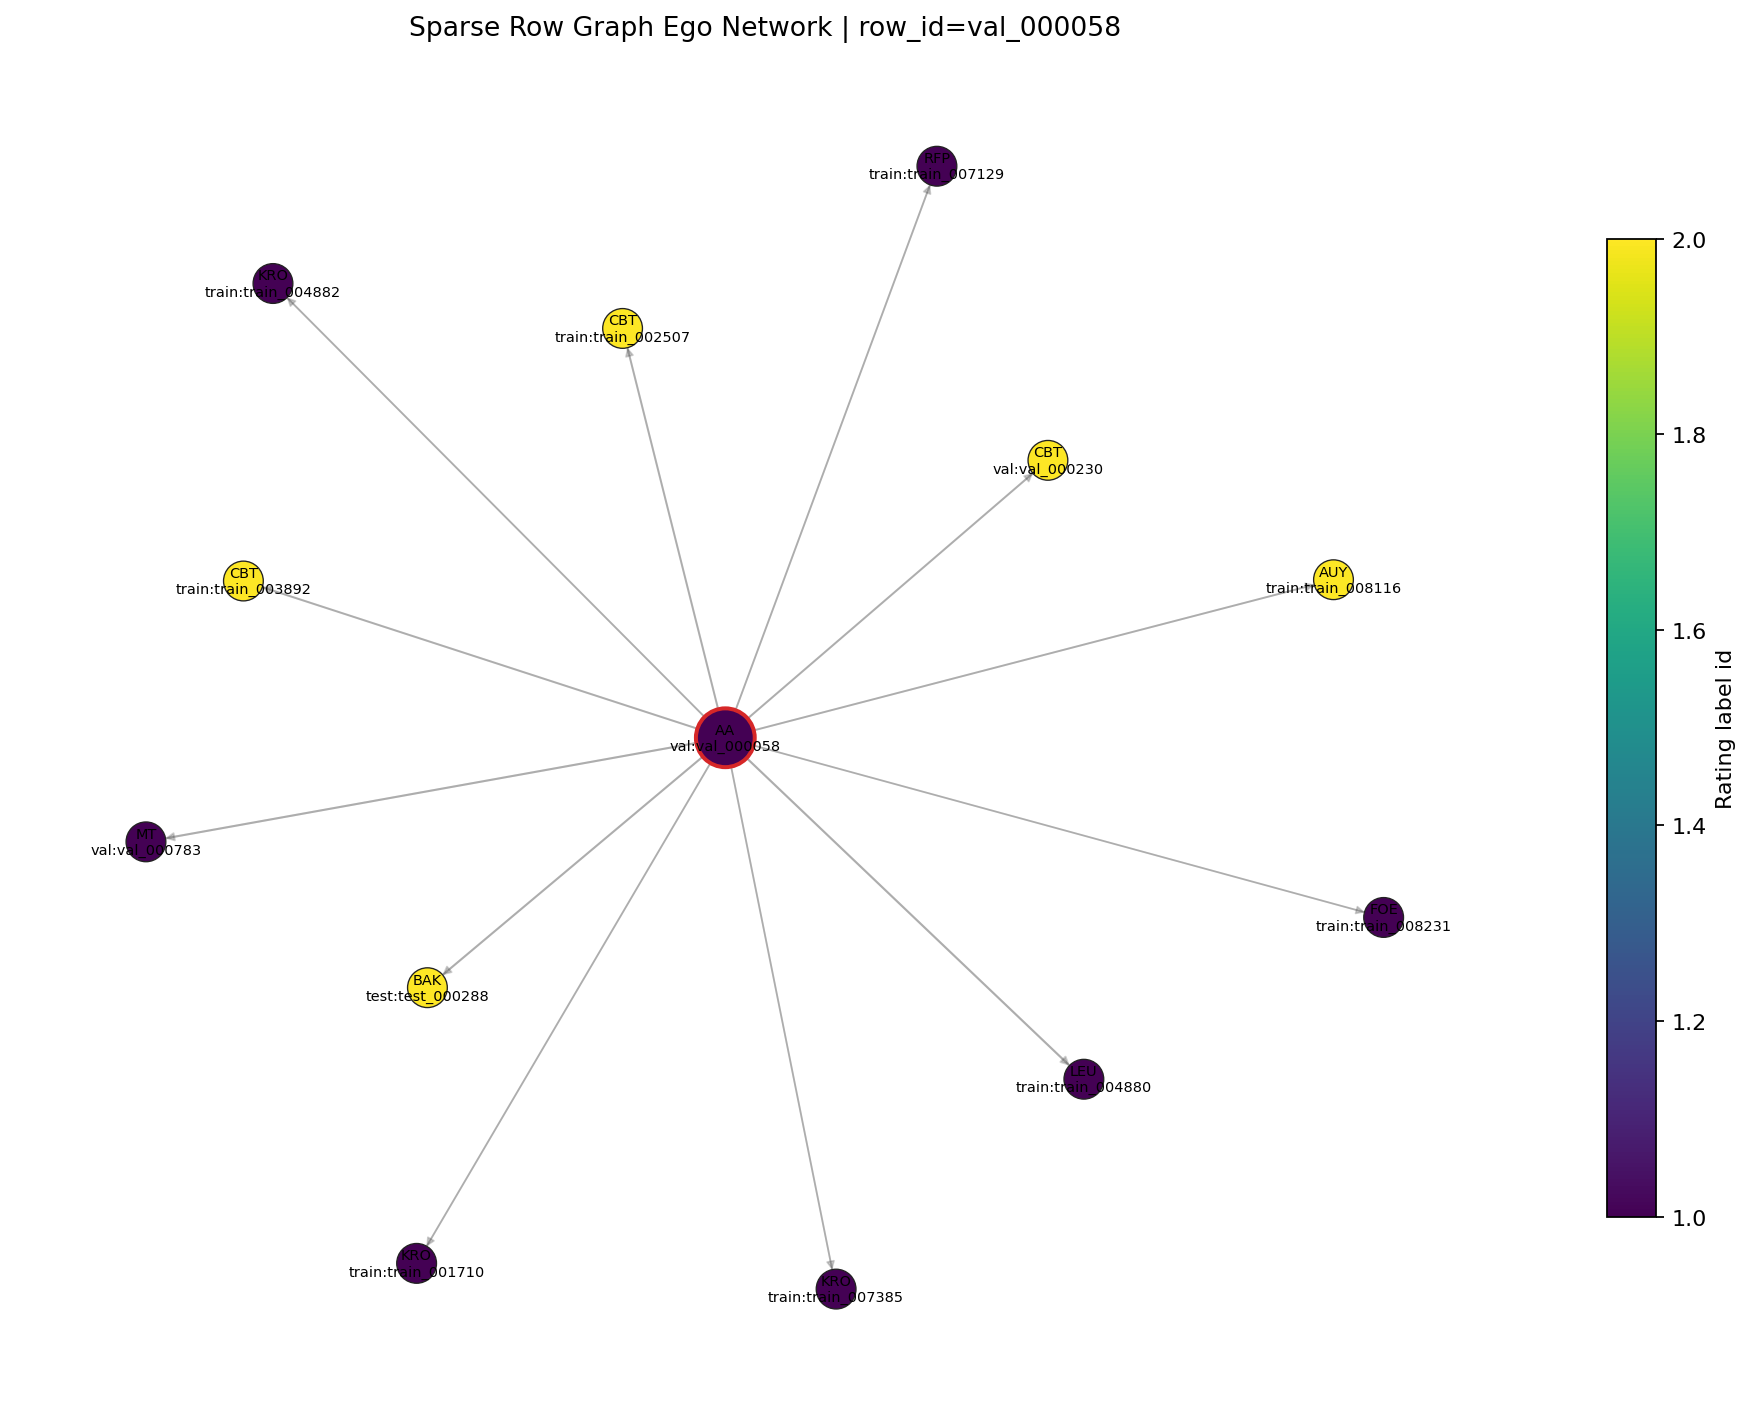

Ego nodes: 13 | ego edges: 24
Saved: /kaggle/working/credit_rating_artifacts/gat_graph_visualization.png


In [7]:
# Visualization: sparse row graph around one validation company-row.
# Yeu cau: chay cell graph va cell model truoc.
if 'model' not in globals() or 'edge_df' not in globals():
    raise RuntimeError('Khong tim thay model hoac edge_df. Hay chay cell graph va cell model truoc.')

import networkx as nx
from matplotlib.colors import Normalize, TwoSlopeNorm

sample_candidates = np.flatnonzero(df['__split__'].eq('val').values)
sample_idx = int(sample_candidates[0]) if len(sample_candidates) else 0

incoming = edge_df[(edge_df['dst'] == sample_idx) & (edge_df['src'] != sample_idx)].copy()
outgoing = edge_df[(edge_df['src'] == sample_idx) & (edge_df['dst'] != sample_idx)].copy()
neighbor_edges = pd.concat([incoming, outgoing], ignore_index=True).drop_duplicates(['dst', 'src'])
neighbor_edges = neighbor_edges.sort_values('norm_weight', ascending=False).head(40).reset_index(drop=True)
display(neighbor_edges[[
    'dst', 'src', 'dst_row_id', 'src_row_id', 'dst_ticker', 'src_ticker',
    'edge_type', 'raw_weight', 'norm_weight',
]].head(20))

G = nx.DiGraph()
node_ids = set([sample_idx])
for row in neighbor_edges.itertuples(index=False):
    node_ids.add(int(row.dst))
    node_ids.add(int(row.src))

for node in sorted(node_ids):
    split = str(df.loc[node, '__split__'])
    ticker = str(df.loc[node, 'ticker'])
    label = f'{ticker}\n{split}:{df.loc[node, "row_id"]}'
    G.add_node(node, label=label, split=split, target=int(df.loc[node, TARGET_COL]))
for row in neighbor_edges.itertuples(index=False):
    G.add_edge(int(row.src), int(row.dst), weight=float(row.norm_weight), edge_type=str(row.edge_type))

fig, ax = plt.subplots(figsize=(12, 9), dpi=160)
pos = nx.spring_layout(G, seed=SEED, k=0.65, iterations=120)
node_values = [G.nodes[n]['target'] for n in G.nodes]
if min(node_values) < max(node_values):
    color_norm = Normalize(vmin=min(node_values), vmax=max(node_values))
else:
    color_norm = Normalize(vmin=0, vmax=max(1, n_classes - 1))
node_colors = plt.get_cmap('viridis')(color_norm(node_values))
node_sizes = [700 if n == sample_idx else 260 + 30 * G.degree(n) for n in G.nodes]
edge_widths = [0.6 + 4.0 * G.edges[e]['weight'] for e in G.edges]
nx.draw_networkx_edges(G, pos, alpha=0.28, width=edge_widths, edge_color='#555555', arrows=True, arrowsize=8, ax=ax)
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    linewidths=[1.8 if n == sample_idx else 0.6 for n in G.nodes],
    edgecolors=['#d62728' if n == sample_idx else '#222222' for n in G.nodes],
    ax=ax,
)
labels = {n: G.nodes[n]['label'] for n in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=6.5, ax=ax)
colorbar = plt.cm.ScalarMappable(cmap='viridis', norm=color_norm)
colorbar.set_array([])
fig.colorbar(colorbar, ax=ax, shrink=0.72, label='Rating label id')
ax.set_title(f'Sparse Row Graph Ego Network | row_id={df.loc[sample_idx, "row_id"]}')
ax.axis('off')
fig.tight_layout()
graph_path = ARTIFACT_DIR / 'gat_graph_visualization.png'
fig.savefig(graph_path, dpi=300, bbox_inches='tight')
plt.show()

print('Ego nodes:', G.number_of_nodes(), '| ego edges:', G.number_of_edges())
print('Saved:', graph_path)


Epoch 001 | TrLoss 0.5016 | VaLoss 0.5282 | Gap 0.0267 | TrCE 0.5016 | VaCE 0.5282 | VaAcc 0.9223 | VaF1 0.8385 | VaC0R 0.7333 | VaC0F2 0.7097 | VaQWK 0.8711 | MetricScore 0.7913 | CkptScore 0.7913 | Balanced True | CtxMask 0.25 | LR 6.00e-04
Epoch 002 | TrLoss 0.4783 | VaLoss 0.5092 | Gap 0.0308 | TrCE 0.4783 | VaCE 0.5092 | VaAcc 0.9223 | VaF1 0.8385 | VaC0R 0.7333 | VaC0F2 0.7097 | VaQWK 0.8711 | MetricScore 0.7909 | CkptScore 0.7909 | Balanced True | CtxMask 0.25 | LR 6.00e-04
Epoch 003 | TrLoss 0.4598 | VaLoss 0.4935 | Gap 0.0337 | TrCE 0.4598 | VaCE 0.4935 | VaAcc 0.9223 | VaF1 0.8385 | VaC0R 0.7333 | VaC0F2 0.7097 | VaQWK 0.8711 | MetricScore 0.7906 | CkptScore 0.7906 | Balanced True | CtxMask 0.24 | LR 6.00e-04
Epoch 004 | TrLoss 0.4446 | VaLoss 0.4802 | Gap 0.0356 | TrCE 0.4446 | VaCE 0.4802 | VaAcc 0.9246 | VaF1 0.8470 | VaC0R 0.7333 | VaC0F2 0.7190 | VaQWK 0.8738 | MetricScore 0.7947 | CkptScore 0.7947 | Balanced True | CtxMask 0.24 | LR 6.00e-04
Epoch 005 | TrLoss 0.4320 | 

,Split,Class0_Threshold,Checkpoint,Checkpoint_Epoch,Persistence_Prior_Scale,Final_Train_CE_Loss,Final_Val_CE_Loss,Final_Loss_Gap,Accuracy,Balanced_Accuracy,...,Weighted_F1,Class0_Precision,Class0_Recall,Class0_F1,Class0_F2,Class0_Support,AUC,QWK,ChgAcc,Ordinal_MAE
0,Val_PersistenceBaseline,NaN,balanced_loss,10,1.25,0.390246,0.429888,0.039643,0.922274,0.854952,...,0.922911,0.628571,0.733333,0.676923,0.709677,30,0.903629,0.871099,0.000000,0.078886
1,Test_PersistenceBaseline,NaN,balanced_loss,10,1.25,0.390246,0.429888,0.039643,0.924550,0.835555,...,0.924838,0.639344,0.661017,0.650000,0.656566,59,0.894924,0.874990,0.000000,0.076030
2,Val_RawArgmax,NaN,balanced_loss,10,1.25,0.390246,0.429888,0.039643,0.923434,0.856142,...,0.923445,0.709677,0.733333,0.721311,0.728477,30,0.944546,0.870684,0.044776,0.077726
3,Test_RawArgmax,NaN,balanced_loss,10,1.25,0.390246,0.429888,0.039643,0.923389,0.824256,...,0.923424,0.637931,0.627119,0.632479,0.629252,59,0.930629,0.869423,0.015385,0.077771
4,Val_Class0Calibrated,NaN,balanced_loss,10,1.25,0.390246,0.429888,0.039643,0.923434,0.856142,...,0.923445,0.709677,0.733333,0.721311,0.728477,30,0.944546,0.870684,0.044776,0.077726
5,Test_Class0Calibrated,NaN,balanced_loss,10,1.25,0.390246,0.429888,0.039643,0.923389,0.824256,...,0.923424,0.637931,0.627119,0.632479,0.629252,59,0.930629,0.869423,0.015385,0.077771


Selected class 0 threshold: None
Final CE loss gap: 0.039643
Saved: /kaggle/working/credit_rating_artifacts/gat_metrics.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_training_history.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_class0_threshold_sweep.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_class0_threshold_summary.csv


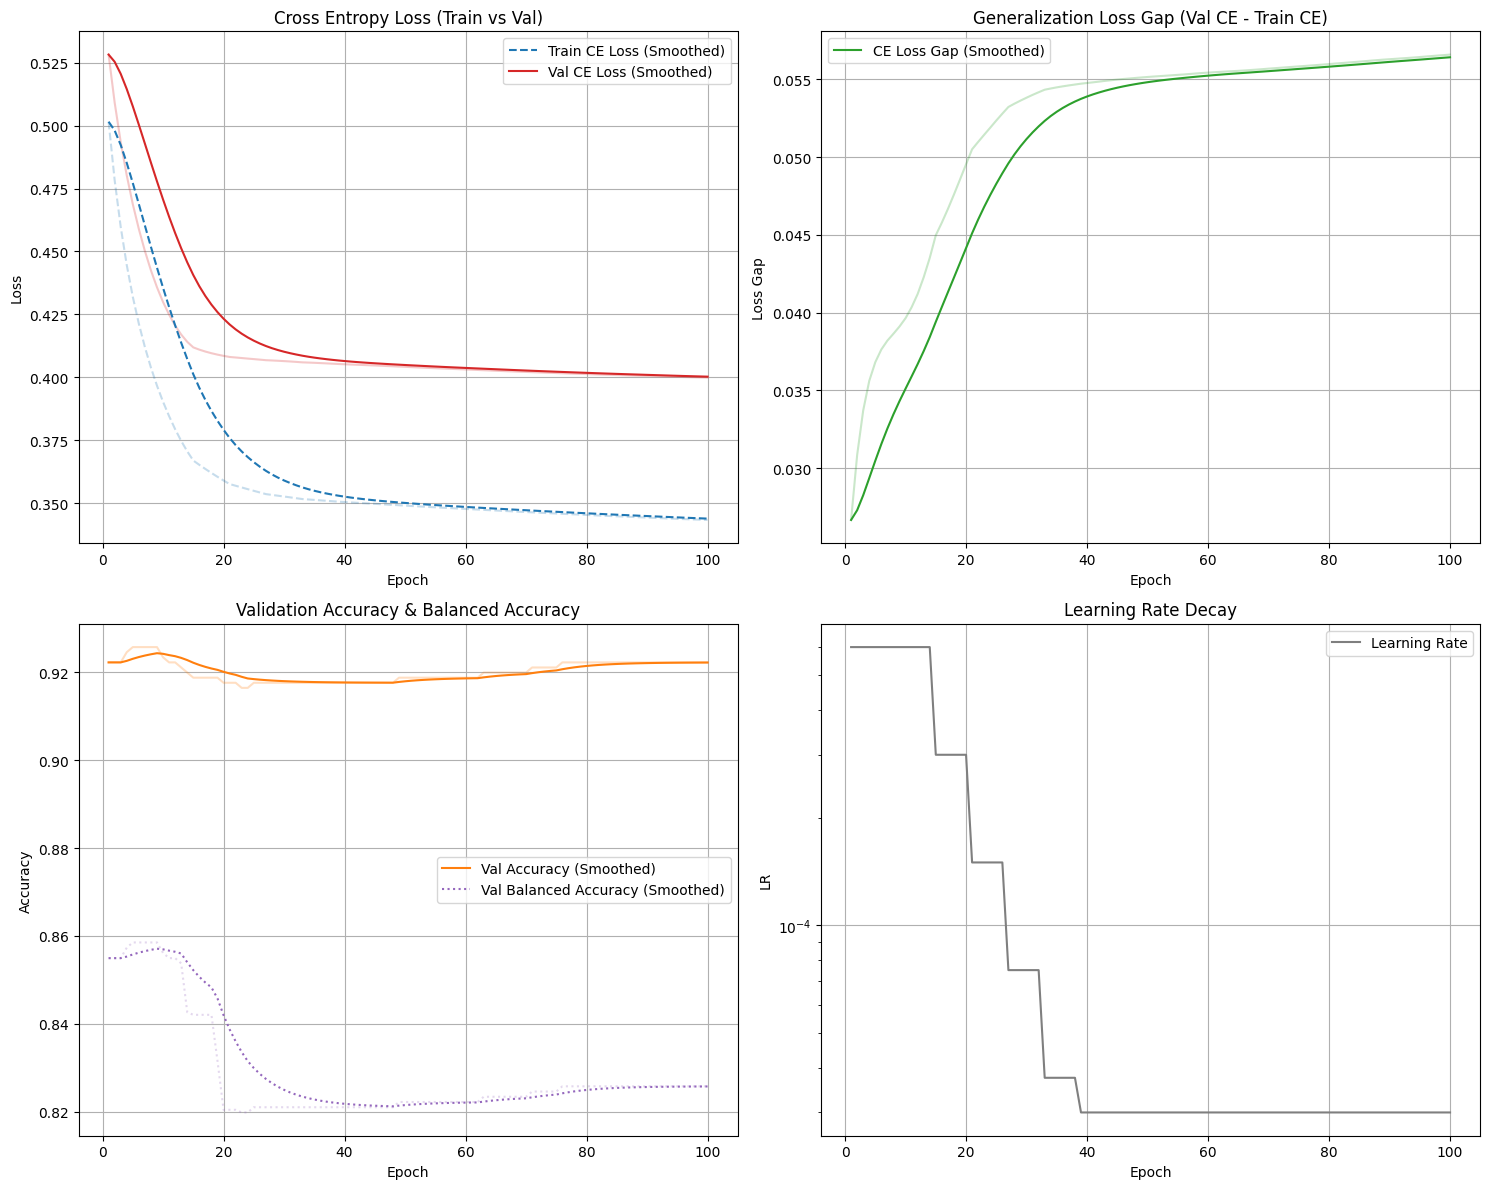

In [8]:
history = {
    'epoch': [],
    'train_Loss': [], 'val_Loss': [],
    'train_CE_Loss': [], 'val_CE_Loss': [],
    'train_NLL': [], 'val_NLL': [],
    'train_Objective': [], 'val_Objective': [],
    'train_Aux_Loss': [], 'val_Aux_Loss': [],
    'val_LossGap': [],
    'train_Accuracy': [], 'val_Accuracy': [],
    'train_Balanced_Accuracy': [], 'val_Balanced_Accuracy': [],
    'train_Macro_F1': [], 'val_Macro_F1': [],
    'train_Class0_Precision': [], 'val_Class0_Precision': [],
    'train_Class0_Recall': [], 'val_Class0_Recall': [],
    'train_Class0_F1': [], 'val_Class0_F1': [],
    'train_Class0_F2': [], 'val_Class0_F2': [],
    'train_ChgAcc': [], 'val_ChgAcc': [],
    'train_Ordinal_MAE': [], 'val_Ordinal_MAE': [],
    'train_AUC': [], 'val_AUC': [],
    'train_QWK': [], 'val_QWK': [],
    'train_PersistenceAcc': [], 'val_PersistenceAcc': [],
    'Learning_Rate': [],
    'context_mask_prob': [],
    'val_MetricScore': [], 'val_CheckpointScore': [],
    'val_BalancedEligible': [],
    'checkpoint_event': [],
}

# Config B parameters
CONTEXT_MASK_START = 0.25
CONTEXT_MASK_END = 0.08
CONTEXT_MASK_WARMUP_EPOCHS = 60

def scheduled_context_mask(epoch):
    progress = min(1.0, max(0.0, (float(epoch) - 1.0) / float(max(1, CONTEXT_MASK_WARMUP_EPOCHS - 1))))
    return CONTEXT_MASK_START + (CONTEXT_MASK_END - CONTEXT_MASK_START) * progress

CHECKPOINT_CONFIG = {
    'mode': 'balanced_loss',
    'balanced_accuracy_floor_drop': 0.003,
    'min_delta': 1e-4,
}

def checkpoint_score(metrics, val_loss, train_loss):
    loss_gap = max(0.0, float(val_loss) - float(train_loss))
    score = (
        0.45 * metrics.get('Accuracy', metrics.get('accuracy'))
        + 0.35 * metrics.get('Macro_F1', metrics.get('macro_f1'))
        + 0.10 * metrics.get('Balanced_Accuracy', metrics.get('balanced_accuracy', metrics.get('Accuracy')))
        - 0.10 * loss_gap
    )
    return score

def persistence_accuracy(mask):
    y_true = y_all[mask].detach().cpu().numpy()
    y_pred = last_y_all[mask].detach().cpu().numpy().astype(int)
    return float(accuracy_score(y_true, y_pred))

train_persistence_acc = persistence_accuracy(train_mask)
val_persistence_acc = persistence_accuracy(val_mask)

best_score = -np.inf
best_state = None
best_epoch = None
best_metric_val_acc = -np.inf
best_payload = {}

best_loss_value = np.inf
best_loss_state = None
best_loss_epoch = None
best_loss_payload = {}

best_balanced_loss = np.inf
best_balanced_metric_score = -np.inf
best_balanced_state = None
best_balanced_epoch = None
best_balanced_payload = {}

patience, no_improve = 100, 0
max_epochs = 100
min_epochs = 20
min_delta = float(CHECKPOINT_CONFIG.get('min_delta', 1e-4))

for epoch in range(1, max_epochs + 1):
    model.train()
    
    # Apply DropEdge graph regularization during training (Config B uses p=0.12)
    train_edge_index, train_edge_weight = apply_dropedge(
        edge_index,
        edge_weight,
        x_all.size(0),
        p=0.12
    )
    
    current_context_mask = scheduled_context_mask(epoch)
    optimizer.zero_grad(set_to_none=True)
    logits = model(
        x_all, last_y_all, sector_all, 
        edge_index=train_edge_index, 
        edge_weight=train_edge_weight, 
        context_mask_prob=current_context_mask
    )
    loss = criterion(logits[train_mask], y_all[train_mask], epoch=epoch)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        logits_eval = model(x_all, last_y_all, sector_all)
        train_loss_parts = criterion.loss_parts(logits_eval[train_mask], y_all[train_mask], epoch=epoch)
        val_loss_parts = criterion.loss_parts(logits_eval[val_mask], y_all[val_mask], epoch=epoch)
        train_total_loss = train_loss_parts['objective']
        val_total_loss = val_loss_parts['objective']
        train_loss = train_total_loss.item()
        val_loss = val_total_loss.item()
        train_ce_loss = train_loss_parts['ce_loss'].item()
        val_ce_loss = val_loss_parts['ce_loss'].item()
        train_aux_loss = train_loss_parts['aux_loss'].item()
        val_aux_loss = val_loss_parts['aux_loss'].item()
        train_nll = float(train_loss_parts['nll'].item())
        val_nll = float(val_loss_parts['nll'].item())
        train_objective = float(train_loss_parts['objective'].item())
        val_objective = float(val_loss_parts['objective'].item())
        tr, _, _, _ = evaluate_logits(logits_eval, train_mask)
        va, _, _, _ = evaluate_logits(logits_eval, val_mask)

    # Step scheduler based on custom composite score
    current_score = checkpoint_score(va, val_ce_loss, train_ce_loss)
    scheduler.step(current_score)
    
    current_lr = optimizer.param_groups[0]['lr']
    val_loss_gap = max(0.0, float(val_ce_loss) - float(train_ce_loss))

    checkpoint_value = val_nll if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else val_objective
    val_selection_score = current_score
    checkpoint_event = []

    # Checkpoint: best composite score
    if current_score > best_score + min_delta:
        best_score = current_score
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        best_metric_val_acc = float(va['Accuracy'])
        best_payload = {
            'val_accuracy': float(va['Accuracy']),
            'val_ce_loss': float(val_ce_loss),
            'train_ce_loss': float(train_ce_loss),
            'val_loss_gap': float(val_loss_gap),
            'metric_score': float(current_score),
            'checkpoint_score': float(val_selection_score),
        }
        checkpoint_event.append('metric')
        no_improve = 0
    else:
        no_improve += 1

    # Checkpoint: best val loss
    if checkpoint_value < best_loss_value - min_delta:
        best_loss_value = float(checkpoint_value)
        best_loss_state = copy.deepcopy(model.state_dict())
        best_loss_epoch = int(epoch)
        best_loss_payload = {
            'val_accuracy': float(va['Accuracy']),
            'val_ce_loss': float(val_ce_loss),
            'train_ce_loss': float(train_ce_loss),
            'val_loss_gap': float(val_loss_gap),
            'metric_score': float(current_score),
            'checkpoint_score': float(val_selection_score),
            'protocol': LOSS_PROTOCOL,
            'val_nll': float(val_nll),
            'val_objective': float(val_objective),
        }
        checkpoint_event.append('protocol_loss')

    # Checkpoint: best balanced loss
    accuracy_floor = best_metric_val_acc - float(CHECKPOINT_CONFIG['balanced_accuracy_floor_drop'])
    balanced_eligible = bool(va['Accuracy'] >= accuracy_floor)
    if balanced_eligible and (
        val_ce_loss < best_balanced_loss - min_delta
        or (abs(val_ce_loss - best_balanced_loss) <= min_delta and current_score > best_balanced_metric_score + min_delta)
    ):
        best_balanced_loss = float(val_ce_loss)
        best_balanced_metric_score = float(current_score)
        best_balanced_state = copy.deepcopy(model.state_dict())
        best_balanced_epoch = int(epoch)
        best_balanced_payload = {
            'val_accuracy': float(va['Accuracy']),
            'val_ce_loss': float(val_ce_loss),
            'train_ce_loss': float(train_ce_loss),
            'val_loss_gap': float(val_loss_gap),
            'metric_score': float(current_score),
            'checkpoint_score': float(val_selection_score),
            'accuracy_floor': float(accuracy_floor),
        }
        checkpoint_event.append('balanced')

    history['epoch'].append(epoch)
    history['train_Loss'].append(float(train_loss))
    history['val_Loss'].append(float(val_loss))
    history['train_CE_Loss'].append(float(train_ce_loss))
    history['val_CE_Loss'].append(float(val_ce_loss))
    history['train_NLL'].append(float(train_nll))
    history['val_NLL'].append(float(val_nll))
    history['train_Objective'].append(float(train_objective))
    history['val_Objective'].append(float(val_objective))
    history['train_Aux_Loss'].append(float(train_aux_loss))
    history['val_Aux_Loss'].append(float(val_aux_loss))
    history['val_LossGap'].append(float(val_loss_gap))
    history['Learning_Rate'].append(float(current_lr))
    history['context_mask_prob'].append(float(current_context_mask))
    history['train_PersistenceAcc'].append(float(train_persistence_acc))
    history['val_PersistenceAcc'].append(float(val_persistence_acc))
    for metric_name in ['Accuracy', 'Balanced_Accuracy', 'Macro_F1', 'Class0_Precision', 'Class0_Recall', 'Class0_F1', 'Class0_F2', 'ChgAcc', 'Ordinal_MAE', 'AUC', 'QWK']:
        val_tr = tr.get(metric_name, tr.get('Accuracy', float('nan')))
        val_va = va.get(metric_name, va.get('Accuracy', float('nan')))
        history[f'train_{metric_name}'].append(float(val_tr) if not (isinstance(val_tr, float) and val_tr != val_tr) else float('nan'))
        history[f'val_{metric_name}'].append(float(val_va) if not (isinstance(val_va, float) and val_va != val_va) else float('nan'))
    history['val_MetricScore'].append(float(current_score))
    history['val_CheckpointScore'].append(float(val_selection_score))
    history['val_BalancedEligible'].append(bool(balanced_eligible))
    history['checkpoint_event'].append('+'.join(checkpoint_event) if checkpoint_event else '')

    print(
        f"Epoch {epoch:03d} | TrLoss {train_loss:.4f} | VaLoss {val_loss:.4f} | "
        f"Gap {val_loss_gap:.4f} | TrCE {train_ce_loss:.4f} | VaCE {val_ce_loss:.4f} | "
        f"VaAcc {va['Accuracy']:.4f} | VaF1 {va['Macro_F1']:.4f} | "
        f"VaC0R {va['Class0_Recall']:.4f} | VaC0F2 {va['Class0_F2']:.4f} | "
        f"VaQWK {va['QWK']:.4f} | MetricScore {current_score:.4f} | "
        f"CkptScore {val_selection_score:.4f} | Balanced {balanced_eligible} | "
        f"CtxMask {current_context_mask:.2f} | LR {current_lr:.2e}"
    )

    if epoch >= min_epochs and no_improve >= patience:
        print(f"Early stopping at epoch {epoch}. Best epoch = {best_epoch}")
        break

# Select and load checkpoint using Priority
balanced_floor = best_metric_val_acc - float(CHECKPOINT_CONFIG['balanced_accuracy_floor_drop'])
if CHECKPOINT_CONFIG['mode'] == 'balanced_loss' and best_balanced_state is not None:
    selected_checkpoint_tag = 'balanced_loss'
    selected_checkpoint_epoch = best_balanced_epoch
    selected_checkpoint_payload = best_balanced_payload
    model.load_state_dict(best_balanced_state)
elif best_state is not None:
    selected_checkpoint_tag = 'metric'
    selected_checkpoint_epoch = best_epoch
    selected_checkpoint_payload = best_payload
    model.load_state_dict(best_state)
elif best_loss_state is not None:
    selected_checkpoint_tag = 'val_NLL' if LOSS_PROTOCOL == BENCHMARK_PROTOCOL else 'val_Objective'
    selected_checkpoint_epoch = best_loss_epoch
    selected_checkpoint_payload = best_loss_payload
    model.load_state_dict(best_loss_state)
else:
    selected_checkpoint_tag = 'final_epoch'
    selected_checkpoint_epoch = int(history['epoch'][-1]) if history['epoch'] else np.nan
    selected_checkpoint_payload = {}

checkpoint_audit = pd.DataFrame([
    {'checkpoint': 'metric', 'epoch': best_epoch, **best_payload},
    {'checkpoint': 'loss', 'epoch': best_loss_epoch, **best_loss_payload},
    {'checkpoint': 'balanced_loss', 'epoch': best_balanced_epoch, **best_balanced_payload},
    {'checkpoint': f'selected:{selected_checkpoint_tag}', 'epoch': selected_checkpoint_epoch, **selected_checkpoint_payload},
])
checkpoint_audit_path = ARTIFACT_DIR / 'gat_checkpoint_audit.csv'
checkpoint_audit.to_csv(checkpoint_audit_path, index=False, encoding='utf-8-sig')
print(f"Selected checkpoint: {selected_checkpoint_tag} at epoch {selected_checkpoint_epoch}")
print('Saved:', checkpoint_audit_path)

model.eval()
with torch.no_grad():
    final_logits, node_embeddings = model(x_all, last_y_all, sector_all, return_embeddings=True)
    final_train_loss_parts = criterion.loss_parts(final_logits[train_mask], y_all[train_mask], epoch=selected_checkpoint_epoch)
    final_val_loss_parts = criterion.loss_parts(final_logits[val_mask], y_all[val_mask], epoch=selected_checkpoint_epoch)
    final_train_total_loss = final_train_loss_parts['objective']
    final_val_total_loss = final_val_loss_parts['objective']

final_train_ce_loss = float(final_train_loss_parts['ce_loss'].item())
final_val_ce_loss = float(final_val_loss_parts['ce_loss'].item())
final_loss_gap = max(0.0, final_val_ce_loss - final_train_ce_loss)

val_raw_metrics, y_val, y_val_raw_pred, val_proba = evaluate_logits(final_logits, val_mask)
test_raw_metrics, y_test, y_test_raw_pred, test_proba = evaluate_logits(final_logits, test_mask)

val_last_y = last_y_all[val_mask].detach().cpu().numpy()
test_last_y = last_y_all[test_mask].detach().cpu().numpy()

class0_threshold = None
class0_threshold_sweep = pd.DataFrame()
class0_threshold_baseline = val_raw_metrics
class0_threshold_selected = {}
if CLASS0_THRESHOLD_CONFIG['enabled']:
    class0_threshold, class0_threshold_sweep, class0_threshold_baseline, class0_threshold_selected = calibrate_class0_threshold(
        y_val,
        val_proba,
        last_y=val_last_y,
        config=CLASS0_THRESHOLD_CONFIG,
    )

val_metrics, y_val, y_val_pred, val_proba = evaluate_logits(final_logits, val_mask, class0_threshold=class0_threshold)
test_metrics, y_test, y_test_pred, test_proba = evaluate_logits(final_logits, test_mask, class0_threshold=class0_threshold)

history_df = pd.DataFrame(history)
history_path = ARTIFACT_DIR / 'gat_training_history.csv'
history_df.to_csv(history_path, index=False, encoding='utf-8-sig')

persistence_val_pred = val_last_y.astype(int)
persistence_test_pred = test_last_y.astype(int)
persistence_val_proba = np.eye(n_classes, dtype=np.float32)[np.clip(persistence_val_pred, 0, n_classes - 1)]
persistence_test_proba = np.eye(n_classes, dtype=np.float32)[np.clip(persistence_test_pred, 0, n_classes - 1)]
persistence_val_metrics = compute_metrics(y_val, persistence_val_pred, persistence_val_proba, n_classes, last_y=val_last_y)
persistence_test_metrics = compute_metrics(y_test, persistence_test_pred, persistence_test_proba, n_classes, last_y=test_last_y)

report_common = {
    'Checkpoint': selected_checkpoint_tag,
    'Checkpoint_Epoch': selected_checkpoint_epoch,
    'Persistence_Prior_Scale': PERSISTENCE_PRIOR_SCALE,
    'Final_Train_CE_Loss': final_train_ce_loss,
    'Final_Val_CE_Loss': final_val_ce_loss,
    'Final_Loss_Gap': final_loss_gap,
}
report = pd.DataFrame([
    {'Split': 'Val_PersistenceBaseline', 'Class0_Threshold': np.nan, **report_common, **persistence_val_metrics},
    {'Split': 'Test_PersistenceBaseline', 'Class0_Threshold': np.nan, **report_common, **persistence_test_metrics},
    {'Split': 'Val_RawArgmax', 'Class0_Threshold': np.nan, **report_common, **val_raw_metrics},
    {'Split': 'Test_RawArgmax', 'Class0_Threshold': np.nan, **report_common, **test_raw_metrics},
    {'Split': 'Val_Class0Calibrated', 'Class0_Threshold': class0_threshold, **report_common, **val_metrics},
    {'Split': 'Test_Class0Calibrated', 'Class0_Threshold': class0_threshold, **report_common, **test_metrics},
])
display(report)

metrics_path = ARTIFACT_DIR / 'gat_metrics.csv'
report.to_csv(metrics_path, index=False, encoding='utf-8-sig')

threshold_sweep_path = ARTIFACT_DIR / 'gat_class0_threshold_sweep.csv'
class0_threshold_sweep.to_csv(threshold_sweep_path, index=False, encoding='utf-8-sig')

threshold_summary_path = ARTIFACT_DIR / 'gat_class0_threshold_summary.csv'
pd.DataFrame([{
    'selected_threshold': class0_threshold,
    'selection_metric': CLASS0_THRESHOLD_CONFIG['metric'],
    'accuracy_floor_drop': CLASS0_THRESHOLD_CONFIG['accuracy_floor_drop'],
    'min_accuracy_gain': CLASS0_THRESHOLD_CONFIG.get('min_accuracy_gain', 0.0),
    'selected_checkpoint': selected_checkpoint_tag,
    'selected_checkpoint_epoch': selected_checkpoint_epoch,
    'final_train_ce_loss': final_train_ce_loss,
    'final_val_ce_loss': final_val_ce_loss,
    'final_loss_gap': final_loss_gap,
    **{f'val_selected_{k}': v for k, v in class0_threshold_selected.items() if isinstance(v, (int, float, np.integer, np.floating))},
}]).to_csv(threshold_summary_path, index=False, encoding='utf-8-sig')

print('Selected class 0 threshold:', class0_threshold)
print('Final CE loss gap:', round(final_loss_gap, 6))
print('Saved:', metrics_path)
print('Saved:', history_path)
print('Saved:', threshold_sweep_path)
print('Saved:', threshold_summary_path)

# ================= PLOT TRAINING CURVES WITH EMA SMOOTHING =================
import matplotlib.pyplot as plt

def smooth_curve(values, alpha=0.85):
    smoothed = []
    if len(values) == 0:
        return smoothed
    last = values[0]
    for v in values:
        if np.isnan(v):
            smoothed.append(np.nan)
            continue
        if np.isnan(last):
            last = v
        last = alpha * last + (1 - alpha) * v
        smoothed.append(last)
    return smoothed

fig, axs = plt.subplots(2, 2, figsize=(15, 12))
axs = axs.ravel()

epochs_list = history['epoch']

# Plot Train & Val Loss
axs[0].plot(epochs_list, history['train_CE_Loss'], color='#1f77b4', alpha=0.25, linestyle='--')
axs[0].plot(epochs_list, history['val_CE_Loss'], color='#d62728', alpha=0.25)
axs[0].plot(epochs_list, smooth_curve(history['train_CE_Loss']), label="Train CE Loss (Smoothed)", color='#1f77b4', linestyle='--')
axs[0].plot(epochs_list, smooth_curve(history['val_CE_Loss']), label="Val CE Loss (Smoothed)", color='#d62728')
axs[0].set_title('Cross Entropy Loss (Train vs Val)')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].grid(True)
axs[0].legend()

# Plot Loss Gap
axs[1].plot(epochs_list, history['val_LossGap'], color='#2ca02c', alpha=0.25)
axs[1].plot(epochs_list, smooth_curve(history['val_LossGap']), label="CE Loss Gap (Smoothed)", color='#2ca02c')
axs[1].set_title('Generalization Loss Gap (Val CE - Train CE)')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss Gap')
axs[1].grid(True)
axs[1].legend()

# Plot Val Accuracy
axs[2].plot(epochs_list, history['val_Accuracy'], color='#ff7f0e', alpha=0.25)
axs[2].plot(epochs_list, history['val_Balanced_Accuracy'], color='#9467bd', alpha=0.25, linestyle=':')
axs[2].plot(epochs_list, smooth_curve(history['val_Accuracy']), label="Val Accuracy (Smoothed)", color='#ff7f0e')
axs[2].plot(epochs_list, smooth_curve(history['val_Balanced_Accuracy']), label="Val Balanced Accuracy (Smoothed)", color='#9467bd', linestyle=':')
axs[2].set_title('Validation Accuracy & Balanced Accuracy')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Accuracy')
axs[2].grid(True)
axs[2].legend()

# Plot Learning Rate
axs[3].plot(epochs_list, history['Learning_Rate'], label="Learning Rate", color='#7f7f7f')
axs[3].set_title('Learning Rate Decay')
axs[3].set_xlabel('Epoch')
axs[3].set_ylabel('LR')
axs[3].set_yscale('log')
axs[3].grid(True)
axs[3].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'gat_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()


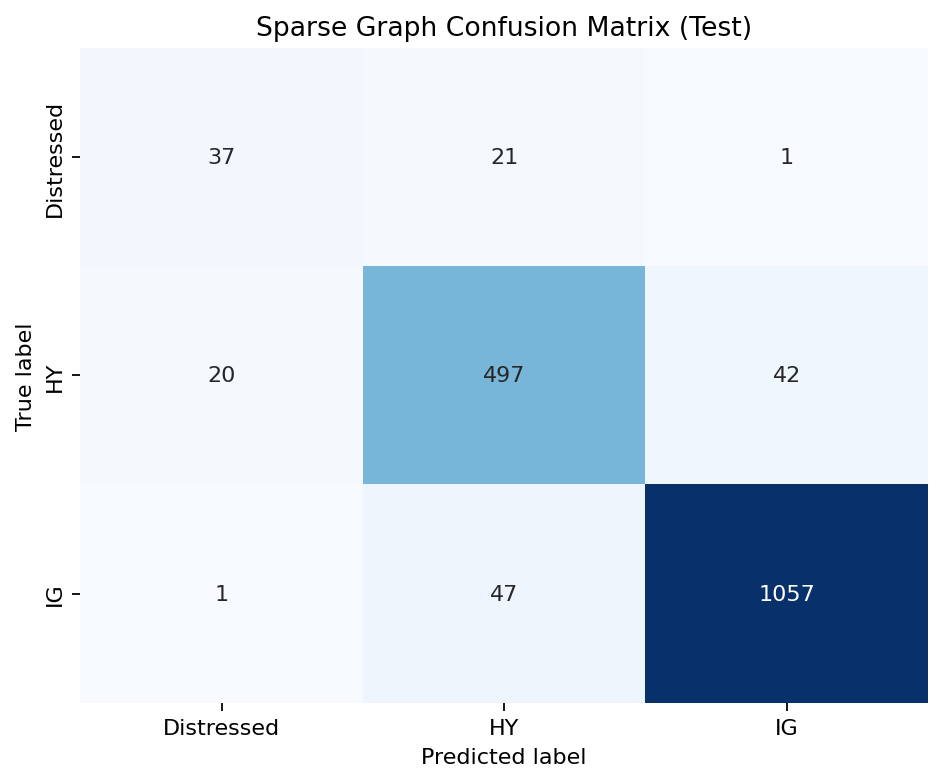

,Distressed,HY,IG
Distressed,37,21,1
HY,20,497,42
IG,1,47,1057


Classification report (test set, class 0 calibrated):
              precision    recall  f1-score   support

  Distressed     0.6379    0.6271    0.6325        59
          HY     0.8796    0.8891    0.8843       559
          IG     0.9609    0.9566    0.9587      1105

    accuracy                         0.9234      1723
   macro avg     0.8262    0.8243    0.8252      1723
weighted avg     0.9235    0.9234    0.9234      1723

Raw argmax class 0 metrics:
{'Class0_Precision': 0.6379, 'Class0_Recall': 0.6271, 'Class0_F1': 0.6325, 'Accuracy': 0.9234}
Calibrated class 0 metrics:
{'Class0_Precision': 0.6379, 'Class0_Recall': 0.6271, 'Class0_F1': 0.6325, 'Accuracy': 0.9234}


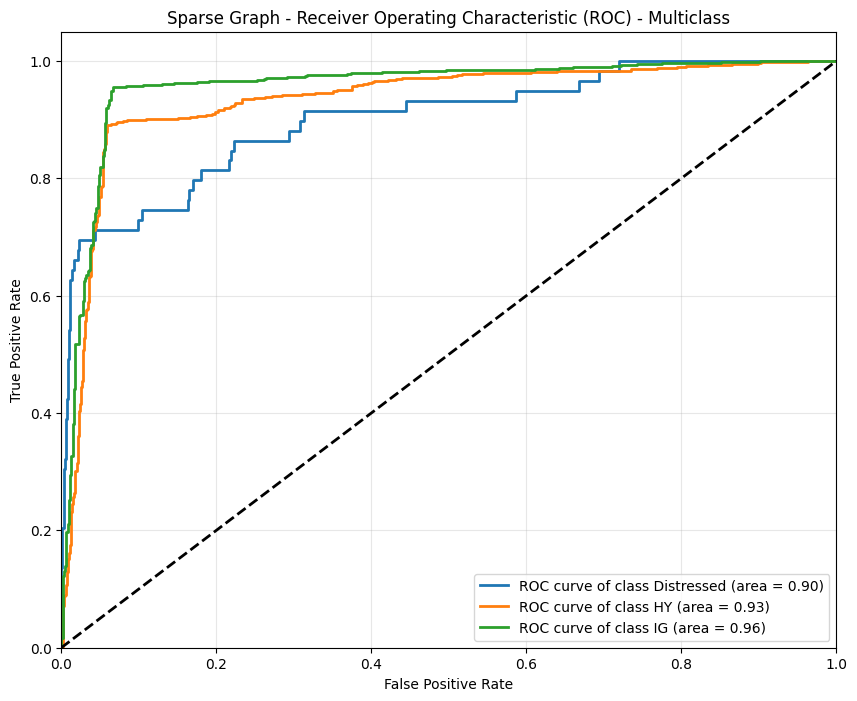

Saved: /kaggle/working/credit_rating_artifacts/gat_test_confusion_matrix.png
Saved: /kaggle/working/credit_rating_artifacts/gat_test_confusion_matrix.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_test_classification_report.csv
Saved: /kaggle/working/credit_rating_artifacts/gat_test_roc_curves.png


In [9]:
id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}
class_labels = [str(id_to_raw_local.get(i, i)) for i in range(n_classes)]
label_ids = list(range(n_classes))

cm = confusion_matrix(y_test, y_test_pred, labels=label_ids)
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)

plt.figure(figsize=(6, 5), dpi=160)
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
threshold_title = f' | class0 threshold={class0_threshold:.2f}' if class0_threshold is not None else ''
plt.title(f'Sparse Graph Confusion Matrix (Test){threshold_title}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
cm_plot_path = ARTIFACT_DIR / 'gat_test_confusion_matrix.png'
plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
plt.show()

display(cm_df)
print('Classification report (test set, class 0 calibrated):')
print(classification_report(
    y_test,
    y_test_pred,
    labels=label_ids,
    target_names=class_labels,
    digits=4,
    zero_division=0,
))

if 'test_raw_metrics' in globals():
    print('Raw argmax class 0 metrics:')
    print({
        'Class0_Precision': round(test_raw_metrics['Class0_Precision'], 4),
        'Class0_Recall': round(test_raw_metrics['Class0_Recall'], 4),
        'Class0_F1': round(test_raw_metrics['Class0_F1'], 4),
        'Accuracy': round(test_raw_metrics['Accuracy'], 4),
    })
    print('Calibrated class 0 metrics:')
    print({
        'Class0_Precision': round(test_metrics['Class0_Precision'], 4),
        'Class0_Recall': round(test_metrics['Class0_Recall'], 4),
        'Class0_F1': round(test_metrics['Class0_F1'], 4),
        'Accuracy': round(test_metrics['Accuracy'], 4),
    })

cls_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        labels=label_ids,
        target_names=class_labels,
        output_dict=True,
        zero_division=0,
    )
).transpose()

cm_csv_path = ARTIFACT_DIR / 'gat_test_confusion_matrix.csv'
cls_csv_path = ARTIFACT_DIR / 'gat_test_classification_report.csv'
cm_df.to_csv(cm_csv_path, encoding='utf-8-sig')
cls_report_df.to_csv(cls_csv_path, encoding='utf-8-sig')

plt.figure(figsize=(10, 8))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba[:, i])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc_val:0.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Sparse Graph - Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
roc_plot_path = ARTIFACT_DIR / 'gat_test_roc_curves.png'
plt.savefig(roc_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', cm_plot_path)
print('Saved:', cm_csv_path)
print('Saved:', cls_csv_path)
print('Saved:', roc_plot_path)


In [10]:
# Export prediction CSVs with the same contract as LSTM for DMF/DCS.
if 'id_to_raw_local' not in globals():
    id_to_raw_local = {v: k for k, v in raw_to_id.items()} if 'raw_to_id' in globals() else {i: i for i in range(n_classes)}

def prediction_frame(split_name, split_mask, y_true, proba, pred=None, class0_threshold=None):
    pred = predict_with_class0_threshold(proba, class0_threshold=class0_threshold) if pred is None else np.asarray(pred).astype(int)
    raw_pred = np.argmax(proba, axis=1).astype(int)
    conf = proba[np.arange(len(pred)), pred]
    rows = df.loc[split_mask.detach().cpu().numpy(), ['row_id', 'ticker', 'company_name', 'rating_date']].copy().reset_index(drop=True)
    rows.insert(0, 'split', split_name)
    rows['rating_date'] = pd.to_datetime(rows['rating_date'], errors='coerce').dt.strftime('%Y-%m-%d').fillna('')
    rows['true_label'] = y_true.astype(int)
    rows['true_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in y_true]
    rows['pred_label'] = pred
    rows['pred_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in pred]
    rows['raw_pred_label'] = raw_pred
    rows['raw_pred_label_name'] = [str(id_to_raw_local.get(int(y), y)) for y in raw_pred]
    rows['class0_threshold'] = np.nan if class0_threshold is None else float(class0_threshold)
    rows['confidence'] = conf.astype(float)
    rows['raw_confidence'] = np.max(proba, axis=1).astype(float)
    for cls_idx in range(proba.shape[1]):
        rows[f'prob_{cls_idx}'] = proba[:, cls_idx].astype(float)
    return rows


gat_val_predictions = prediction_frame('val', val_mask, y_val, val_proba, pred=y_val_pred, class0_threshold=class0_threshold)
gat_test_predictions = prediction_frame('test', test_mask, y_test, test_proba, pred=y_test_pred, class0_threshold=class0_threshold)

val_csv = DMF_ARTIFACT_DIR / 'gat_val_predictions.csv'
test_csv = DMF_ARTIFACT_DIR / 'gat_test_predictions.csv'
gat_val_predictions.to_csv(val_csv, index=False, encoding='utf-8-sig')
gat_test_predictions.to_csv(test_csv, index=False, encoding='utf-8-sig')

np.save(DMF_ARTIFACT_DIR / 'gat_val_embeddings.npy', node_embeddings[val_mask].detach().cpu().numpy())
np.save(DMF_ARTIFACT_DIR / 'gat_test_embeddings.npy', node_embeddings[test_mask].detach().cpu().numpy())
np.save(ARTIFACT_DIR / 'gat_val_proba.npy', val_proba.astype(np.float32))
np.save(ARTIFACT_DIR / 'gat_test_proba.npy', test_proba.astype(np.float32))
np.save(ARTIFACT_DIR / 'gat_y_val.npy', y_val.astype(int))
np.save(ARTIFACT_DIR / 'gat_y_test.npy', y_test.astype(int))

label_contract.to_csv(DMF_ARTIFACT_DIR / 'label_mapping.csv', index=False, encoding='utf-8-sig')
print(f'[OK] Saved DMF val CSV  -> {val_csv}')
print(f'[OK] Saved DMF test CSV -> {test_csv}')
print(gat_test_predictions.head())


# Two-tier probability calibration: OOF validation, full-validation test temperature.
_temperature_result = cross_fit_temperature_scaling(
    val_proba,
    y_val,
    test_proba,
    max_splits=5,
    seed=42,
)
calibrated_validation_probabilities = _temperature_result.validation_probabilities.astype(np.float32)
calibrated_test_probabilities = _temperature_result.test_probabilities.astype(np.float32)
np.save(ARTIFACT_DIR / "gat_cal_val_proba.npy", calibrated_validation_probabilities)
np.save(ARTIFACT_DIR / "gat_cal_test_proba.npy", calibrated_test_probabilities)
calibration_report = pd.DataFrame([
    {"Split": "Val", "Calibration": "raw", **probability_report(y_val, val_proba, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Val", "Calibration": "temperature_oof", **probability_report(y_val, calibrated_validation_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "raw", **probability_report(y_test, test_proba, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
    {"Split": "Test", "Calibration": "temperature", **probability_report(y_test, calibrated_test_probabilities, protocol=LOSS_PROTOCOL, ordinal_lambda=ORDINAL_LAMBDA)},
])
calibration_report["Temperature"] = float(_temperature_result.temperature)
calibration_report.to_csv(ARTIFACT_DIR / "gat_two_tier_metrics.csv", index=False)
print(
    f"[OK] Temperature={_temperature_result.temperature:.6f} | "
    f"folds={_temperature_result.n_splits} | protocol={LOSS_PROTOCOL}"
)


# Preserve raw prob_* columns and add calibrated columns for downstream fusion.
for _class_id in range(calibrated_validation_probabilities.shape[1]):
    gat_val_predictions[f"cal_prob_{_class_id}"] = calibrated_validation_probabilities[:, _class_id].astype(float)
    gat_test_predictions[f"cal_prob_{_class_id}"] = calibrated_test_probabilities[:, _class_id].astype(float)
gat_val_predictions.to_csv(val_csv, index=False, encoding="utf-8-sig")
gat_test_predictions.to_csv(test_csv, index=False, encoding="utf-8-sig")
print("[OK] Added calibrated probability columns to:", val_csv, test_csv)


[OK] Saved DMF val CSV  -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/gat_val_predictions.csv
[OK] Saved DMF test CSV -> /kaggle/working/credit_rating_artifacts/dmf_gat_lstm/gat_test_predictions.csv
  split       row_id ticker                   company_name rating_date  \
0  test  test_000040    AAL  American Airlines Group, Inc.  2013-11-12   
1  test  test_000815    AAP       ADVANCE AUTO PARTS, INC.  2013-05-29   
2  test  test_000326    AAP       Advance Auto Parts, Inc.  2013-11-25   
3  test  test_000813   AAPL                     Apple Inc.  2015-05-28   
4  test  test_000387   AAPL                     Apple Inc.  2016-06-03   

   true_label true_label_name  pred_label pred_label_name  raw_pred_label  \
0           1              HY           1              HY               1   
1           2              IG           2              IG               2   
2           2              IG           2              IG               2   
3           2              IG         

In [11]:
# Diagnostics: class 0 threshold trade-off and false negatives.
has_sweep = 'class0_threshold_sweep' in globals() and not class0_threshold_sweep.empty
if not has_sweep:
    print('[WARN] class0_threshold_sweep is empty or not defined. Skipping threshold sweep display.')
else:
    display_cols = [
        'class0_threshold', 'Accuracy', 'Macro_F1',
        'Class0_Precision', 'Class0_Recall', 'Class0_F1', 'Class0_F2',
    ]
    threshold_view = class0_threshold_sweep[display_cols].sort_values(
        ['Class0_F2', 'Accuracy', 'Macro_F1'],
        ascending=False,
    ).head(12)
    display(threshold_view)

    class0_tradeoff_path = ARTIFACT_DIR / 'gat_class0_threshold_top_candidates.csv'
    threshold_view.to_csv(class0_tradeoff_path, index=False, encoding='utf-8-sig')
    print('Saved:', class0_tradeoff_path)


test_rows = df.loc[test_mask.detach().cpu().numpy(), [
    'row_id', 'ticker', 'company_name', 'rating_date', 'sector',
    TARGET_COL, 'last_y',
]].copy().reset_index(drop=True)
test_rows['pred_label'] = y_test_pred.astype(int)
test_rows['raw_pred_label'] = y_test_raw_pred.astype(int)
for cls_idx in range(test_proba.shape[1]):
    test_rows[f'prob_{cls_idx}'] = test_proba[:, cls_idx]

class0_error_mask = (test_rows[TARGET_COL].astype(int) == CLASS0_LABEL_ID) & (test_rows['pred_label'] != CLASS0_LABEL_ID)
class0_false_negatives = test_rows.loc[class0_error_mask].sort_values('prob_0', ascending=False)
class0_false_negative_path = ARTIFACT_DIR / 'gat_class0_false_negatives.csv'
class0_false_negatives.to_csv(class0_false_negative_path, index=False, encoding='utf-8-sig')

print('Class 0 confusion by last_y:')
display(pd.crosstab(
    test_rows.loc[test_rows[TARGET_COL].astype(int).eq(CLASS0_LABEL_ID), 'last_y'],
    test_rows.loc[test_rows[TARGET_COL].astype(int).eq(CLASS0_LABEL_ID), 'pred_label'],
    rownames=['last_y'],
    colnames=['pred_label'],
))

print('Top class 0 false negatives by prob_0:')
display(class0_false_negatives.head(20))

if has_sweep:
    print('Saved:', class0_tradeoff_path)
print('Saved:', class0_false_negative_path)


[WARN] class0_threshold_sweep is empty or not defined. Skipping threshold sweep display.
Class 0 confusion by last_y:


pred_label,0,1,2
last_y,,,
0,37,1,1
1,0,20,0


Top class 0 false negatives by prob_0:


,row_id,ticker,company_name,rating_date,sector,rating_detail,last_y,pred_label,raw_pred_label,prob_0,prob_1,prob_2
1602,test_000211,UNIT,Uniti Group Inc.,2016-12-12,4,0,0,2,2,0.395846,0.207232,0.396922
63,test_000034,AMD,"Advanced Micro Devices, Inc.",2015-04-21,10,0,1,1,1,0.321470,0.521461,0.157069
205,test_001604,BTE,Baytex Energy Corp,2016-02-03,5,0,1,1,1,0.240982,0.543786,0.215231
785,test_000381,IO,Ion Geophysical Corporation,2016-10-14,5,0,0,1,1,0.231289,0.555870,0.212841
1463,test_000576,SXC,"SunCoke Energy, Inc.",2016-02-03,1,0,1,1,1,0.180980,0.601409,0.217610
232,test_000860,BZH,Beazer Homes USA Inc.,2014-06-13,8,0,1,1,1,0.151649,0.789878,0.058473
230,test_001293,BZH,"Beazer Homes USA, Inc.",2012-09-06,8,0,1,1,1,0.150105,0.804146,0.045749
1487,test_000811,TECK,Teck Resources Limited,2016-05-23,8,0,1,1,1,0.136418,0.784715,0.078868
1524,test_001666,THC,Tenet Healthcare Corp.,2015-07-08,7,0,1,1,1,0.136286,0.806431,0.057283
209,test_001714,BTU,PEABODY ENERGY CORPORATION,2014-10-22,5,0,1,1,1,0.135853,0.789592,0.074555


Saved: /kaggle/working/credit_rating_artifacts/gat_class0_false_negatives.csv


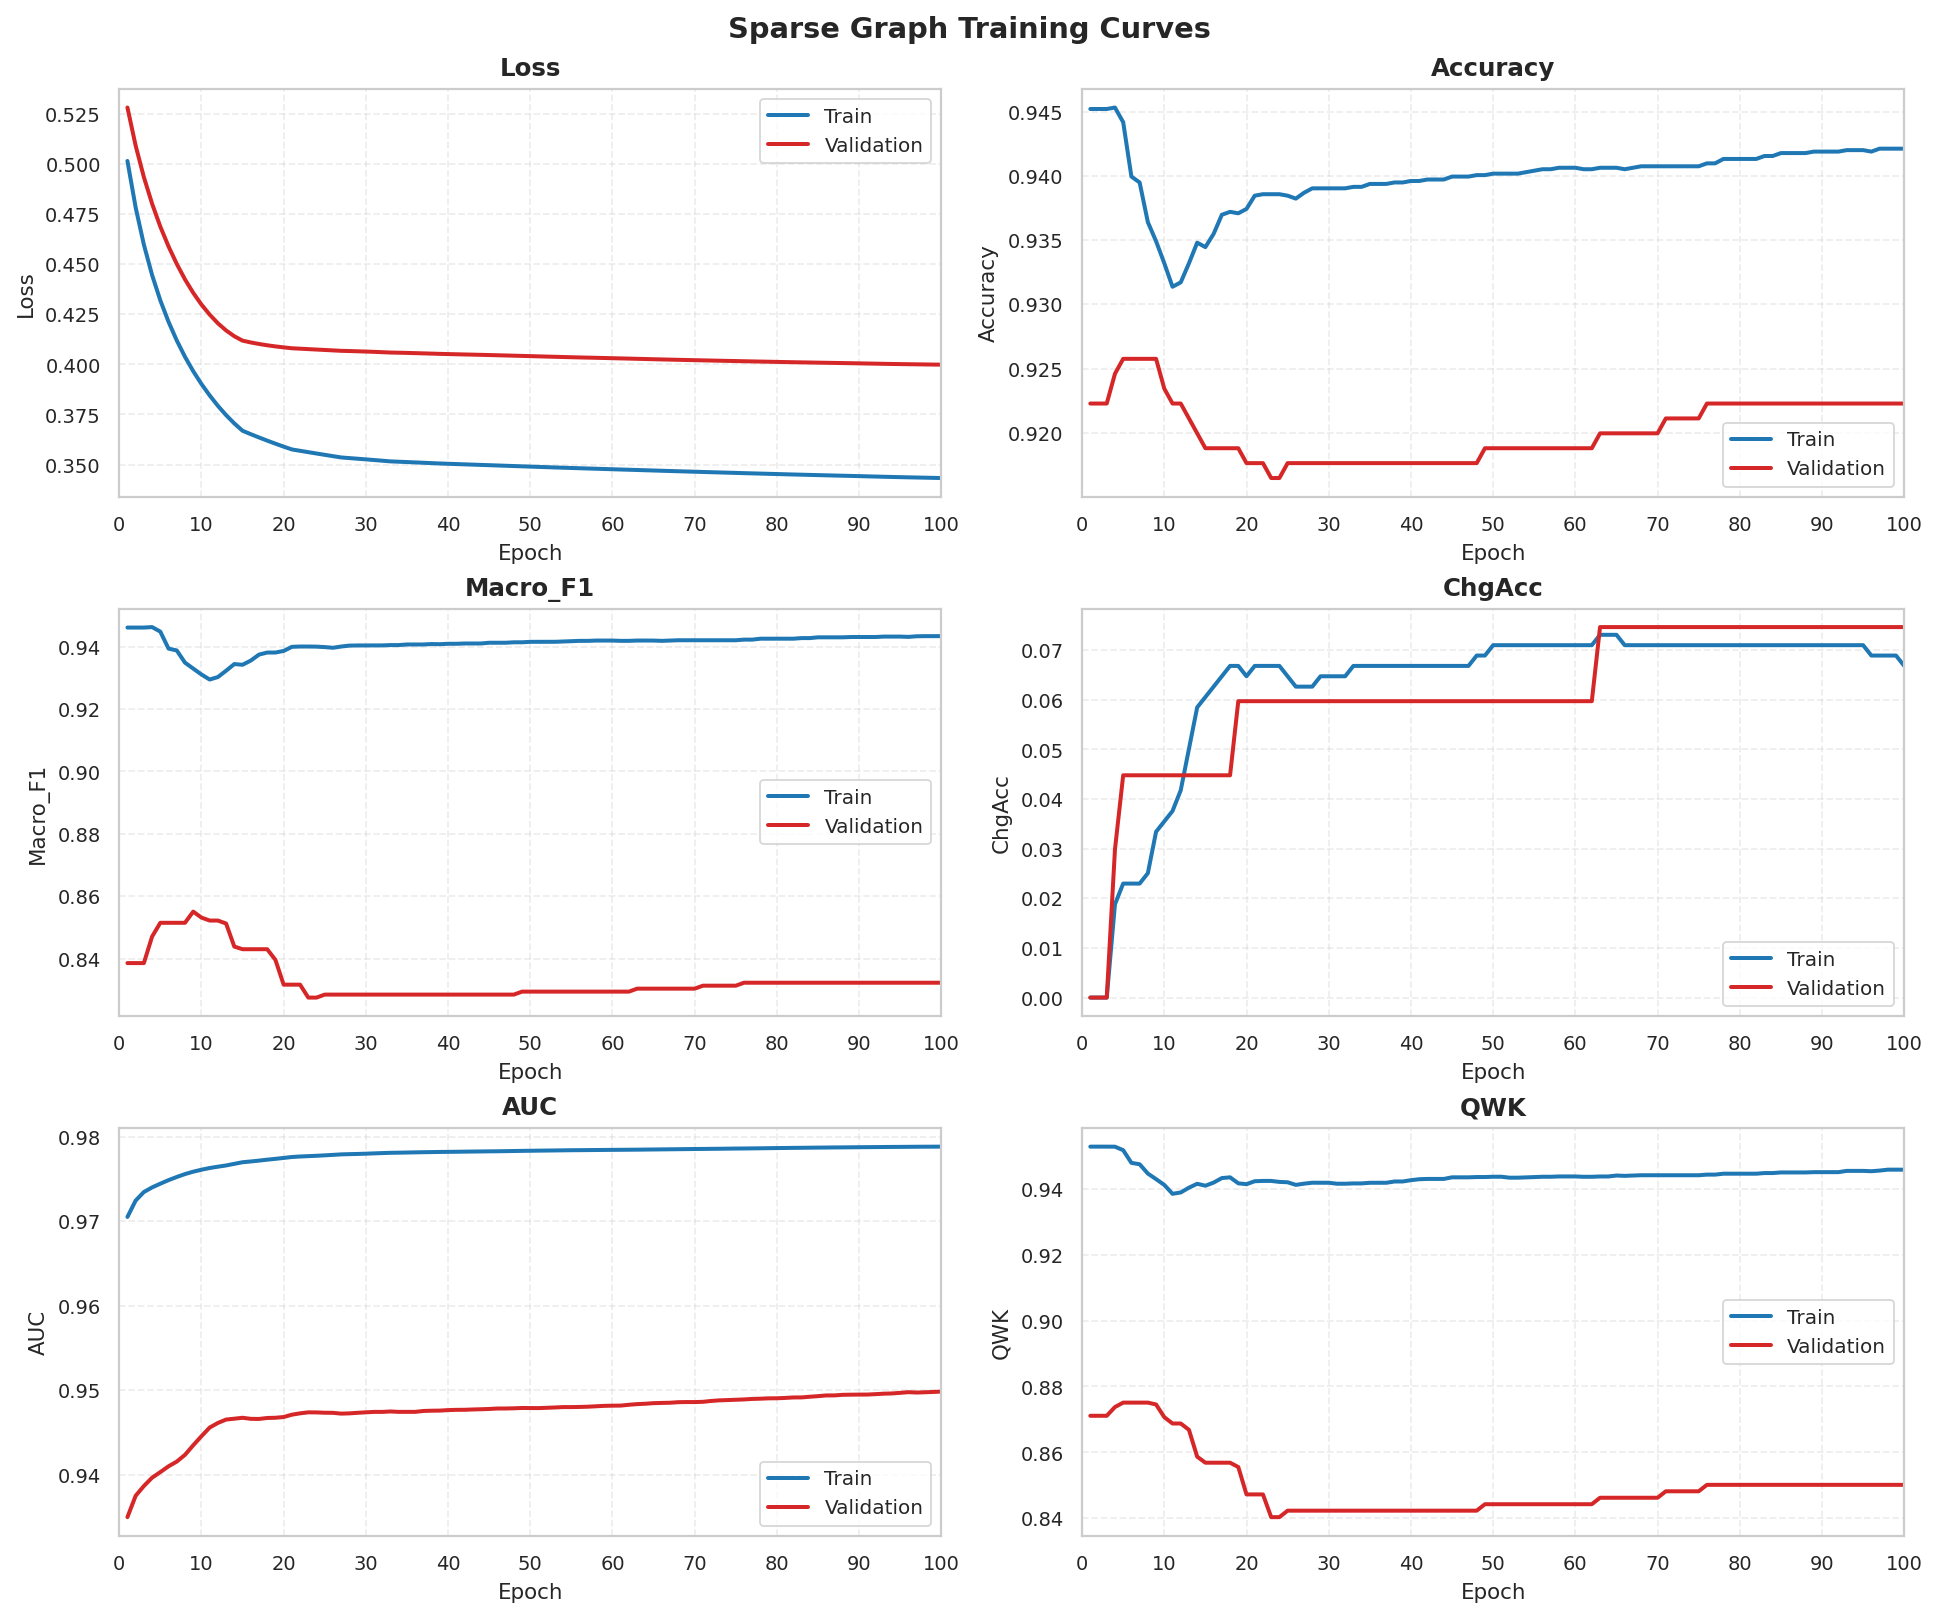

Saved: /kaggle/working/credit_rating_artifacts/gat_training_curves.png


In [12]:
# Visualization: training curves
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

from matplotlib.ticker import MultipleLocator

sns.set_theme(style='whitegrid', context='paper')
metrics = ['Loss', 'Accuracy', 'Macro_F1', 'ChgAcc', 'AUC', 'QWK']
loss_train_col = 'train_CE_Loss' if 'train_CE_Loss' in history_df.columns else 'train_Loss'
loss_val_col = 'val_CE_Loss' if 'val_CE_Loss' in history_df.columns else 'val_Loss'
required_cols = [loss_train_col, loss_val_col] + [f'train_{m}' for m in metrics if m != 'Loss'] + [f'val_{m}' for m in metrics if m != 'Loss']
missing = [c for c in required_cols if c not in history_df.columns]
if missing:
    raise RuntimeError(f'Thieu cot trong history_df: {missing}. Hay chay lai cell huan luyen.')

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=160, constrained_layout=True)
axes = axes.ravel()
max_epoch = int(history_df['epoch'].max())

for ax, metric in zip(axes, metrics):
    train_col = loss_train_col if metric == 'Loss' else f'train_{metric}'
    val_col = loss_val_col if metric == 'Loss' else f'val_{metric}'
    ax.plot(history_df['epoch'], history_df[train_col], label='Train', linewidth=1.8, color='#1f77b4')
    ax.plot(history_df['epoch'], history_df[val_col], label='Validation', linewidth=1.8, color='#d62728')
    ax.set_title(metric, fontsize=11, fontweight='semibold')
    ax.set_xlabel('Epoch')
    ax.set_xlim(0, max_epoch)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.set_ylabel(metric)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(frameon=True, fontsize=9)

fig.suptitle('Sparse Graph Training Curves', fontsize=13, fontweight='bold')
curve_path = ARTIFACT_DIR / 'gat_training_curves.png'
fig.savefig(curve_path, dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', curve_path)


In [13]:
if 'history_df' not in globals():
    raise RuntimeError('Khong tim thay history_df. Hay chay lai cell huan luyen truoc.')

history_df = history_df.copy()
history_df['val_MetricScore'] = history_df.apply(
    lambda row: selection_score({
        'Accuracy': row['val_Accuracy'],
        'QWK': row['val_QWK'],
        'Macro_F1': row['val_Macro_F1'],
        'Class0_F2': row['val_Class0_F2'],
        'ChgAcc': row['val_ChgAcc'],
        'Ordinal_MAE': row['val_Ordinal_MAE'],
    }),
    axis=1,
)
history_df['val_CheckpointScore'] = history_df.apply(
    lambda row: checkpoint_score(
        {
            'Accuracy': row['val_Accuracy'],
            'QWK': row['val_QWK'],
            'Macro_F1': row['val_Macro_F1'],
            'Class0_F2': row['val_Class0_F2'],
            'ChgAcc': row['val_ChgAcc'],
            'Ordinal_MAE': row['val_Ordinal_MAE'],
        },
        row['val_CE_Loss'] if 'val_CE_Loss' in row else row['val_Loss'],
        row['train_CE_Loss'] if 'train_CE_Loss' in row else row['train_Loss'],
    ),
    axis=1,
)
loss_for_min_col = 'val_CE_Loss' if 'val_CE_Loss' in history_df.columns else 'val_Loss'
train_loss_for_gap_col = 'train_CE_Loss' if 'train_CE_Loss' in history_df.columns else 'train_Loss'
history_df['val_LossGap'] = history_df.get('val_LossGap', history_df[loss_for_min_col] - history_df[train_loss_for_gap_col])

selected_epoch = selected_checkpoint_epoch if 'selected_checkpoint_epoch' in globals() else None
if selected_epoch is not None and not pd.isna(selected_epoch) and (history_df['epoch'] == int(selected_epoch)).any():
    best_epoch_idx = history_df.index[history_df['epoch'] == int(selected_epoch)][0]
else:
    best_epoch_idx = history_df['val_CheckpointScore'].idxmax()

min_val_loss_idx = history_df[loss_for_min_col].idxmin()
best_val_acc_idx = history_df['val_Accuracy'].idxmax()
best_gap_idx = history_df['val_LossGap'].idxmin()
best_epoch = int(history_df.loc[best_epoch_idx, 'epoch']) if 'epoch' in history_df.columns else int(best_epoch_idx) + 1
min_val_loss_epoch = int(history_df.loc[min_val_loss_idx, 'epoch']) if 'epoch' in history_df.columns else int(min_val_loss_idx) + 1
best_val_acc_epoch = int(history_df.loc[best_val_acc_idx, 'epoch']) if 'epoch' in history_df.columns else int(best_val_acc_idx) + 1
best_gap_epoch = int(history_df.loc[best_gap_idx, 'epoch']) if 'epoch' in history_df.columns else int(best_gap_idx) + 1

row = history_df.loc[best_epoch_idx]
best_train_loss = float(row['train_Loss'])
best_val_loss = float(row['val_Loss'])
best_train_ce_loss = float(row['train_CE_Loss']) if 'train_CE_Loss' in row else best_train_loss
best_val_ce_loss = float(row['val_CE_Loss']) if 'val_CE_Loss' in row else best_val_loss
best_val_aux_loss = float(row['val_Aux_Loss']) if 'val_Aux_Loss' in row else 0.0
best_loss_gap = float(row['val_LossGap'])
best_train_acc = float(row['train_Accuracy'])
best_val_acc = float(row['val_Accuracy'])
best_val_class0_recall = float(row['val_Class0_Recall'])
best_val_class0_f2 = float(row['val_Class0_F2'])
checkpoint_tag = selected_checkpoint_tag if 'selected_checkpoint_tag' in globals() else CHECKPOINT_CONFIG.get('mode', 'unknown')

print(f'Best metrics (selected checkpoint: {checkpoint_tag}):')
print(f'Train Loss:       {best_train_loss:.6f} @ epoch {best_epoch}')
print(f'Val Loss:         {best_val_loss:.6f} @ epoch {best_epoch}')
print(f'Train CE Loss:    {best_train_ce_loss:.6f} @ epoch {best_epoch}')
print(f'Val CE Loss:      {best_val_ce_loss:.6f} @ epoch {best_epoch}')
print(f'CE Loss Gap:      {best_loss_gap:.6f} @ epoch {best_epoch}')
print(f'Val Aux Loss:     {best_val_aux_loss:.6f} @ epoch {best_epoch}')
print(f'Train Acc:        {best_train_acc:.6f} @ epoch {best_epoch}')
print(f'Val Acc:          {best_val_acc:.6f} @ epoch {best_epoch}')
print(f'Val Class0 Recall:{best_val_class0_recall:.6f} @ epoch {best_epoch}')
print(f'Val Class0 F2:    {best_val_class0_f2:.6f} @ epoch {best_epoch}')
print(f'Min Val Loss:     {float(history_df.loc[min_val_loss_idx, loss_for_min_col]):.6f} @ epoch {min_val_loss_epoch}')
print(f'Best Val Acc:     {float(history_df.loc[best_val_acc_idx, "val_Accuracy"]):.6f} @ epoch {best_val_acc_epoch}')
print(f'Min CE Loss Gap:  {float(history_df.loc[best_gap_idx, "val_LossGap"]):.6f} @ epoch {best_gap_epoch}')

summary_df = pd.DataFrame([
    {
        'checkpoint': checkpoint_tag,
        'epoch': best_epoch,
        'train_loss': best_train_loss,
        'val_loss': best_val_loss,
        'train_ce_loss': best_train_ce_loss,
        'val_ce_loss': best_val_ce_loss,
        'ce_loss_gap': best_loss_gap,
        'val_aux_loss': best_val_aux_loss,
        'train_acc': best_train_acc,
        'val_acc': best_val_acc,
        'val_class0_recall': best_val_class0_recall,
        'val_class0_f2': best_val_class0_f2,
        'val_metric_score': float(row['val_MetricScore']),
        'val_checkpoint_score': float(row['val_CheckpointScore']),
        'checkpoint_mode': CHECKPOINT_CONFIG.get('mode', 'unknown') if 'CHECKPOINT_CONFIG' in globals() else 'unknown',
        'balanced_accuracy_floor_drop': CHECKPOINT_CONFIG.get('balanced_accuracy_floor_drop', np.nan) if 'CHECKPOINT_CONFIG' in globals() else np.nan,
        'min_val_loss_epoch': min_val_loss_epoch,
        'min_val_loss': float(history_df.loc[min_val_loss_idx, loss_for_min_col]),
        'min_val_loss_source': loss_for_min_col,
        'best_val_acc_epoch': best_val_acc_epoch,
        'best_val_acc': float(history_df.loc[best_val_acc_idx, 'val_Accuracy']),
        'best_gap_epoch': best_gap_epoch,
        'best_gap': float(history_df.loc[best_gap_idx, 'val_LossGap']),
        'learning_rate': float(row['Learning_Rate']) if 'Learning_Rate' in row else np.nan,
        'selected_class0_threshold': class0_threshold if 'class0_threshold' in globals() else np.nan,
        'persistence_prior_scale': PERSISTENCE_PRIOR_SCALE if 'PERSISTENCE_PRIOR_SCALE' in globals() else np.nan,
    }
])

training_summary_path = ARTIFACT_DIR / 'gat_training_summary.csv'
summary_df.to_csv(training_summary_path, index=False, encoding='utf-8-sig')
display(summary_df)
print('Saved:', training_summary_path)


Best metrics (selected checkpoint: balanced_loss):
Train Loss:       0.390246 @ epoch 10
Val Loss:         0.429888 @ epoch 10
Train CE Loss:    0.390246 @ epoch 10
Val CE Loss:      0.429888 @ epoch 10
CE Loss Gap:      0.039643 @ epoch 10
Val Aux Loss:     0.000000 @ epoch 10
Train Acc:        0.933196 @ epoch 10
Val Acc:          0.923434 @ epoch 10
Val Class0 Recall:0.733333 @ epoch 10
Val Class0 F2:    0.728477 @ epoch 10
Min Val Loss:     0.399871 @ epoch 100
Best Val Acc:     0.925754 @ epoch 5
Min CE Loss Gap:  0.026673 @ epoch 1


,checkpoint,epoch,train_loss,val_loss,train_ce_loss,val_ce_loss,ce_loss_gap,val_aux_loss,train_acc,val_acc,...,min_val_loss_epoch,min_val_loss,min_val_loss_source,best_val_acc_epoch,best_val_acc,best_gap_epoch,best_gap,learning_rate,selected_class0_threshold,persistence_prior_scale
0,balanced_loss,10,0.390246,0.429888,0.390246,0.429888,0.039643,0.0,0.933196,0.923434,...,100,0.399871,val_CE_Loss,5,0.925754,1,0.026673,0.0006,None,1.25


Saved: /kaggle/working/credit_rating_artifacts/gat_training_summary.csv


## xAI Captum GradientSHAP + LIME Interpretation

Phan xAI duoc trinh bay theo huong paper-ready cho bai toan xep hang tin dung doanh nghiep:

1. **Global Captum GradientSHAP drivers**: cac feature tai chinh/delta nao anh huong lon nhat tren tap test.
2. **Local "Why this class?"**: voi tung doanh nghiep mau, tach feature dang ung ho va chong lai lop duoc giai thich.
3. **Per-class explanation**: giai thich tung lop rating, khong chi lop argmax, de so sanh cac lop gan nhau theo ordinal risk.
4. **LIME local consistency**: LIME dung cung view feature tai chinh voi SHAP, nhung probability mac dinh lay truc tiep tu model/fusion output cua notebook.
5. **Temporal/fusion context**: baseline neural uu tien financial sequence view; ensemble/DMF giai thich tren probability inputs vi day la input that cua tang ket hop.

Luu y: GradientSHAP/LIME giai thich hanh vi cua model, khong duoc dien giai nhu quan he nhan qua tai chinh.


In [ ]:
# ============================================================
# xAI Captum GradientSHAP + LIME aligned with Transformer-LSTM presentation
# Main artifacts:
#   {model_key}_financial_shap_importance_by_class.csv
#   {model_key}_financial_shap_global_importance.csv
#   {model_key}_financial_shap_local_decisions.csv
#   {model_key}_financial_lime_local_decisions.csv
# ============================================================
SHAP_FINANCIAL_ENABLED = True
LIME_FINANCIAL_ENABLED = True
XAI_MODEL_KEY = "gat"
XAI_MODEL_LABEL = "GAT"
XAI_RANDOM_STATE = SEED if "SEED" in globals() else 42
XAI_LOCAL_SAMPLE_COUNT = 1
XAI_LOCAL_TOP_FEATURES = 10
XAI_FINANCIAL_REDUCER = "mean"  # {"mean", "last"}; used when reducing sequence windows.
XAI_EXPLAIN_CLASS_IDS = None  # None = explain all classes; set e.g. [0, 2] to focus.
XAI_ROW_IDS = None  # Optional explicit row_id override; formats differ across model families.
XAI_SHARED_ROW_ID = "000518"  # Canonical zero-padded row in data/processed/test.csv.
XAI_SHARED_SAMPLE = {"ticker": "KOS", "company_name": "Kosmos Energy, Ltd.", "rating_date": "2016-02-09"}
XAI_REQUIRE_SHARED_SAMPLE = True  # Never silently explain a different company/date.
XAI_BACKGROUND_SIZE = 80
SHAP_MAX_SAMPLES = 12
GRADIENT_SHAP_N_SAMPLES = 64
GRADIENT_SHAP_STDEV = 0.05
XAI_PROXY_MAX_ROWS = 2500
XAI_PROXY_EPOCHS = 220
LIME_NUM_SAMPLES = 600
LIME_USE_DIRECT_MODEL_PROBA = True
XAI_BEESWARM_TOP_FEATURES = 15
XAI_LIME_PLOT_TOP_RULES = 15
XAI_LIME_INSTANCE_TOP_RULES = 8

import math
import sys
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
except Exception as exc:
    raise RuntimeError("xAI GradientSHAP requires PyTorch for the differentiable attribution head.") from exc


def _xai_artifact_dir():
    path = globals().get("ARTIFACT_DIR", globals().get("DMF_ARTIFACT_DIR", None))
    if path is None:
        path = Path("/kaggle/working/credit_rating_artifacts") if globals().get("IN_KAGGLE", False) else Path("credit_rating_artifacts")
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def _xai_normalize_proba(pred):
    pred = np.asarray(pred, dtype=np.float64)
    if pred.ndim == 1:
        pred = pred.reshape(1, -1)
    pred = np.clip(pred, 1e-9, 1.0)
    return pred / pred.sum(axis=1, keepdims=True)


def _xai_class_names(n_cls):
    if "class_names" in globals() and len(class_names) > 0:
        names = [str(x) for x in class_names]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    if "id_to_name" in globals():
        return [str(id_to_name.get(i, i)) for i in range(n_cls)]
    if "id_to_raw" in globals():
        return [str(id_to_raw.get(i, i)) for i in range(n_cls)]
    if "raw_to_id" in globals():
        inv = {int(v): k for k, v in raw_to_id.items()}
        return [str(inv.get(i, i)) for i in range(n_cls)]
    if "le" in globals() and hasattr(le, "classes_"):
        names = [str(x) for x in le.classes_]
        return names[:n_cls] if len(names) >= n_cls else names + [str(i) for i in range(len(names), n_cls)]
    return [str(i) for i in range(n_cls)]


def _xai_resolve_class_ids(class_ids, n_cls):
    if class_ids is None:
        return list(range(n_cls))
    out = []
    for class_id in class_ids:
        class_id = int(class_id)
        if class_id < 0 or class_id >= n_cls:
            raise ValueError(f"Invalid xAI class id {class_id}; expected 0..{n_cls - 1}.")
        if class_id not in out:
            out.append(class_id)
    if not out:
        raise ValueError("XAI_EXPLAIN_CLASS_IDS resolved to an empty class list.")
    return out


def _xai_prob_columns(frame, prefix=None):
    if prefix is None:
        cols = [c for c in frame.columns if str(c).startswith("prob_")]
    else:
        cols = [c for c in frame.columns if str(c).startswith(f"{prefix}_prob_")]

    def suffix_num(name):
        try:
            return int(str(name).split("_")[-1])
        except Exception:
            return 10**9
    return sorted(cols, key=suffix_num)


def _xai_get_proba():
    for name in ["dmf_probs", "fp", "test_proba", "test_probs", "weighted_probs", "soft_probs", "y_test_proba"]:
        if name in globals():
            arr = np.asarray(globals()[name])
            if arr.ndim == 2 and arr.shape[0] > 0:
                return _xai_normalize_proba(arr), name
    if "model" in globals() and "X_test" in globals() and hasattr(model, "predict_proba"):
        X_arr = X_test.values if isinstance(X_test, pd.DataFrame) else np.asarray(X_test)
        return _xai_normalize_proba(model.predict_proba(X_arr)), "model.predict_proba(X_test)"
    for frame_name in ["test_predictions", "test_results", "test_result_df", "test_results_df", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            cols = _xai_prob_columns(frame)
            if cols:
                return _xai_normalize_proba(frame[cols].to_numpy(dtype=float)), frame_name
    raise RuntimeError("Kh?ng t?m th?y probability matrix cho xAI. H?y ch?y cell inference/evaluation tr??c.")


_XAI_CANONICAL_FINANCIAL_FEATURES = [
    "current_ratio",
    "debt_equity_ratio",
    "gross_profit_margin",
    "operating_profit_margin",
    "ebit_margin",
    "pretax_profit_margin",
    "net_profit_margin",
    "asset_turnover",
    "roe",
    "roa",
    "operating_cashflow_ps",
    "free_cashflow_ps",
]


def _xai_original_financial_feature_names():
    out = []
    for source_name in ["FINANCIAL_FEATURES", "MODEL_FEATURES", "feature_cols", "financial_cols"]:
        values = globals().get(source_name, [])
        if values is None:
            continue
        try:
            names = [str(v) for v in values]
        except TypeError:
            continue
        for col in _XAI_CANONICAL_FINANCIAL_FEATURES:
            if col in names and col not in out:
                out.append(col)
    return out if out else list(_XAI_CANONICAL_FINANCIAL_FEATURES)


def _xai_financial_indices_from_names(names):
    names = [str(c) for c in names]
    wanted = _xai_original_financial_feature_names()
    cols = [c for c in wanted if c in names]
    idx = [names.index(c) for c in cols]
    return idx, cols


def _xai_frame_financial_values(frame):
    cols = [c for c in _xai_original_financial_feature_names() if c in frame.columns]
    if cols:
        return frame[cols].to_numpy(dtype=np.float64), [str(c) for c in cols]
    return None, []


def _xai_reduce_sequence_to_original_financial(seq, candidate_names):
    seq = np.asarray(seq, dtype=np.float64)
    idx, cols = _xai_financial_indices_from_names(candidate_names)
    if idx:
        return seq[:, :, idx].mean(axis=1), cols
    return seq.mean(axis=1), [str(c) for c in candidate_names]


def _xai_get_feature_view(proba):
    if "test_ds" in globals() and hasattr(test_ds, "samples") and len(test_ds.samples) > 0:
        seq = np.stack([s[0] for s in test_ds.samples], axis=0).astype(np.float64)
        candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(seq.shape[-1])]))
        X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(seq, candidate_names)
        return X_fin, financial_cols, "original_financial_sequence_mean"
    if "test_X_all" in globals():
        arr = np.asarray(test_X_all, dtype=np.float64)
        if arr.ndim == 3:
            candidate_names = globals().get("MODEL_FEATURES", globals().get("FINANCIAL_FEATURES", [f"feature_{i}" for i in range(arr.shape[-1])]))
            X_fin, financial_cols = _xai_reduce_sequence_to_original_financial(arr, candidate_names)
            return X_fin, financial_cols, "original_financial_sequence_mean"
        if arr.ndim == 2:
            candidate_names = globals().get("flat_feature_names", [f"feature_{i}" for i in range(arr.shape[1])])
            idx, financial_cols = _xai_financial_indices_from_names(candidate_names)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_flat_features"
            if "MODEL_FEATURES" in globals() and arr.shape[1] == len(MODEL_FEATURES):
                idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
                if idx:
                    return arr[:, idx], financial_cols, "original_financial_tabular_features"
            return arr, [str(c) for c in candidate_names], "flattened_sequence"
    if "X_test" in globals():
        if isinstance(X_test, pd.DataFrame):
            X_fin, financial_cols = _xai_frame_financial_values(X_test)
            if financial_cols:
                return X_fin, financial_cols, "original_financial_tabular_features"
            arr = X_test.values
        else:
            arr = np.asarray(X_test)
        arr = np.asarray(arr, dtype=np.float64)
        if "MODEL_FEATURES" in globals() and arr.ndim == 2 and arr.shape[1] == len(MODEL_FEATURES):
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return arr[:, idx], financial_cols, "original_financial_tabular_features"
        if "MODEL_FEATURES" in globals() and "INPUT_SIZE" in globals() and arr.ndim == 2 and arr.shape[1] >= int(INPUT_SIZE) * len(MODEL_FEATURES):
            n_base = len(MODEL_FEATURES)
            window = arr[:, :int(INPUT_SIZE) * n_base].reshape(arr.shape[0], int(INPUT_SIZE), n_base)
            idx, financial_cols = _xai_financial_indices_from_names(MODEL_FEATURES)
            if idx:
                return window[:, :, idx].mean(axis=1), financial_cols, "original_financial_tabular_window_mean"
        cols = list(X_test.columns) if isinstance(X_test, pd.DataFrame) else [f"feature_{i}" for i in range(arr.shape[1])]
        idx, financial_cols = _xai_financial_indices_from_names(cols)
        if idx:
            return arr[:, idx], financial_cols, "original_financial_tabular_features"
        return arr, [str(c) for c in cols], "tabular_features"
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        X_fin, financial_cols = _xai_frame_financial_values(frame)
        if financial_cols:
            return X_fin, financial_cols, "df_test_mask_original_financial_features"
    for frame_name in ["test_df", "df_test", "test_rows", "out"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame):
            frame = globals()[frame_name]
            X_fin, financial_cols = _xai_frame_financial_values(frame)
            if financial_cols:
                return X_fin, financial_cols, f"{frame_name}_original_financial_features"
            prob_cols = []
            for prefix in ["tlstm", "gat", "lstm", "tcn", "patchtst", "xgboost", "lightgbm", "dmf"]:
                prob_cols.extend(_xai_prob_columns(frame, prefix=prefix))
            if prob_cols:
                return frame[prob_cols].to_numpy(dtype=np.float64), [str(c) for c in prob_cols], f"{frame_name}_probability_inputs"
    if "test_probas" in globals() and isinstance(test_probas, list) and len(test_probas) > 0:
        mats = [np.asarray(p, dtype=np.float64) for p in test_probas]
        if all(m.ndim == 2 for m in mats):
            names = globals().get("MODEL_NAMES", [f"model_{i}" for i in range(len(mats))])
            feature_cols = []
            for model_name, mat in zip(names, mats):
                for class_idx in range(mat.shape[1]):
                    feature_cols.append(f"{model_name}_prob_{class_idx}")
            return np.concatenate(mats, axis=1), feature_cols, "ensemble_probability_inputs"
    return np.asarray(proba, dtype=np.float64), [f"predicted_prob_{i}" for i in range(proba.shape[1])], "model_probability_vector"


def _xai_metadata(n_rows):
    meta_cols = ["row_id", "ticker", "company_name", "rating_date", "sector", "true_label", "true_label_name"]
    for frame_name in ["test_df", "df_test", "test_rows", "out", "test_predictions", "test_results_df"]:
        if frame_name in globals() and isinstance(globals()[frame_name], pd.DataFrame) and len(globals()[frame_name]) >= n_rows:
            frame = globals()[frame_name].reset_index(drop=True)
            cols = [c for c in meta_cols if c in frame.columns]
            if cols:
                return frame.loc[:n_rows - 1, cols].copy()
    if "df" in globals() and "test_mask" in globals():
        mask = test_mask.detach().cpu().numpy() if hasattr(test_mask, "detach") else np.asarray(test_mask)
        frame = df.loc[mask].reset_index(drop=True)
        cols = [c for c in meta_cols if c in frame.columns]
        if cols and len(frame) >= n_rows:
            return frame.loc[:n_rows - 1, cols].copy()
    meta = pd.DataFrame({"test_index": np.arange(n_rows, dtype=int)})
    if "y_test" in globals() and len(y_test) >= n_rows:
        meta["true_label"] = np.asarray(y_test[:n_rows], dtype=int)
    elif "y_true" in globals() and len(y_true) >= n_rows:
        meta["true_label"] = np.asarray(y_true[:n_rows], dtype=int)
    return meta


def _xai_shared_sample_id():
    ticker = str(XAI_SHARED_SAMPLE.get("ticker", "")).strip().upper()
    rating_date = pd.to_datetime(XAI_SHARED_SAMPLE.get("rating_date", ""), errors="coerce")
    date_key = rating_date.strftime("%Y-%m-%d") if not pd.isna(rating_date) else str(XAI_SHARED_SAMPLE.get("rating_date", "")).strip()
    sample_key = f"{ticker}|{date_key}"
    if sample_key != "KOS|2016-02-09":
        raise ValueError(f"XAI_SHARED_ROW_ID={XAI_SHARED_ROW_ID} no longer maps to the expected sample: {sample_key}.")
    return str(XAI_SHARED_ROW_ID).zfill(6)


def _xai_shared_sample_mask(meta):
    mask = np.ones(len(meta), dtype=bool)
    required = [key for key, value in XAI_SHARED_SAMPLE.items() if str(value).strip()]
    missing = [key for key in required if key not in meta.columns]
    if missing:
        if XAI_REQUIRE_SHARED_SAMPLE:
            raise KeyError(f"Cannot resolve shared xAI sample {_xai_shared_sample_id()}: missing metadata columns {missing}.")
        return np.zeros(len(meta), dtype=bool)
    for key in required:
        expected = XAI_SHARED_SAMPLE[key]
        if key == "rating_date":
            parsed_values = meta[key].map(lambda value: pd.to_datetime(value, errors="coerce"))
            values = parsed_values.map(lambda value: value.strftime("%Y-%m-%d") if not pd.isna(value) else "")
            expected_date = pd.to_datetime(expected, errors="coerce")
            expected_key = expected_date.strftime("%Y-%m-%d") if not pd.isna(expected_date) else str(expected).strip()
            mask &= values.fillna(meta[key].astype(str).str.strip()).eq(expected_key).to_numpy()
        else:
            values = meta[key].fillna("").astype(str).str.strip().str.casefold()
            mask &= values.eq(str(expected).strip().casefold()).to_numpy()
    return mask


def _xai_select_indices(meta, proba):
    n_rows = len(meta)
    if XAI_ROW_IDS is not None:
        if "row_id" not in meta.columns:
            if XAI_REQUIRE_SHARED_SAMPLE:
                raise KeyError("XAI_ROW_IDS was set, but xAI metadata has no row_id column.")
        else:
            wanted = {str(x) for x in XAI_ROW_IDS}
            idx = [int(i) for i, row_id in enumerate(meta["row_id"].astype(str)) if row_id in wanted]
            if idx:
                return idx[:XAI_LOCAL_SAMPLE_COUNT]
            if XAI_REQUIRE_SHARED_SAMPLE:
                raise ValueError(f"Requested XAI_ROW_IDS={sorted(wanted)} are absent from this notebook test metadata.")
    shared_idx = np.flatnonzero(_xai_shared_sample_mask(meta)).astype(int).tolist()
    if len(shared_idx) == 1:
        return shared_idx
    if len(shared_idx) > 1:
        raise ValueError(f"Shared xAI sample {_xai_shared_sample_id()} is ambiguous: matched indices={shared_idx[:10]}.")
    if XAI_REQUIRE_SHARED_SAMPLE:
        raise ValueError(f"Shared xAI sample {_xai_shared_sample_id()} was not found in this notebook test metadata.")
    confidence = proba.max(axis=1)
    ranked = np.argsort(-confidence)
    selected = []
    preds = proba.argmax(axis=1)
    for class_id in np.unique(preds[ranked]):
        class_ranked = [int(i) for i in ranked if preds[i] == class_id]
        if class_ranked:
            selected.append(class_ranked[0])
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    for i in ranked:
        i = int(i)
        if i not in selected:
            selected.append(i)
        if len(selected) >= XAI_LOCAL_SAMPLE_COUNT:
            break
    return selected


class _XAIProbabilityHead(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        hidden = int(min(96, max(16, 2 * n_features)))
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x):
        return torch.softmax(self.net(x.float()), dim=1)


def _xai_train_probability_head(X_view, proba):
    rng = np.random.default_rng(XAI_RANDOM_STATE)
    X_view = np.asarray(X_view, dtype=np.float64)
    proba = _xai_normalize_proba(proba)
    center = np.nanmedian(X_view, axis=0)
    scale = np.nanstd(X_view, axis=0)
    scale = np.where(scale < 1e-8, 1.0, scale)
    X_std = np.nan_to_num((X_view - center) / scale, nan=0.0, posinf=0.0, neginf=0.0)
    n_rows = len(X_std)
    fit_idx = np.arange(n_rows)
    if n_rows > XAI_PROXY_MAX_ROWS:
        fit_idx = rng.choice(n_rows, size=XAI_PROXY_MAX_ROWS, replace=False)
    device_xai = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    head = _XAIProbabilityHead(X_std.shape[1], proba.shape[1]).to(device_xai)
    x_train = torch.tensor(X_std[fit_idx], dtype=torch.float32, device=device_xai)
    y_train = torch.tensor(proba[fit_idx], dtype=torch.float32, device=device_xai)
    opt = torch.optim.AdamW(head.parameters(), lr=0.01, weight_decay=1e-4)
    head.train()
    for _ in range(int(XAI_PROXY_EPOCHS)):
        opt.zero_grad(set_to_none=True)
        pred = head(x_train)
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        opt.step()
    head.eval()
    with torch.no_grad():
        pred_all = head(torch.tensor(X_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    fidelity = {
        "proxy_mse": float(np.mean((pred_all - proba) ** 2)),
        "proxy_argmax_agreement": float(np.mean(pred_all.argmax(axis=1) == proba.argmax(axis=1))),
    }
    return head, X_std.astype(np.float32), center, scale, device_xai, fidelity


def _xai_predict_from_head(head, center, scale, device_xai, x_batch):
    x_batch = np.asarray(x_batch, dtype=np.float64)
    if x_batch.ndim == 1:
        x_batch = x_batch.reshape(1, -1)
    x_std = np.nan_to_num((x_batch - center) / scale, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    with torch.no_grad():
        pred = head(torch.tensor(x_std, dtype=torch.float32, device=device_xai)).detach().cpu().numpy()
    return _xai_normalize_proba(pred)


def _xai_gradientshap_attributions(head, X_std, sample_indices, background_indices, class_ids, device_xai):
    x_samples = torch.tensor(X_std[sample_indices], dtype=torch.float32, device=device_xai)
    baselines = torch.tensor(X_std[background_indices], dtype=torch.float32, device=device_xai)
    method = "captum_gradientshap_probability_head"
    attributions = {}
    try:
        from captum.attr import GradientShap
        gs = GradientShap(head)
        for class_id in class_ids:
            attr = gs.attribute(
                x_samples,
                baselines=baselines,
                target=int(class_id),
                n_samples=int(GRADIENT_SHAP_N_SAMPLES),
                stdevs=float(GRADIENT_SHAP_STDEV),
            )
            attributions[int(class_id)] = attr.detach().cpu().numpy()
    except Exception as exc:
        method = f"expected_gradients_fallback: {type(exc).__name__}"
        rng = np.random.default_rng(XAI_RANDOM_STATE)
        for class_id in class_ids:
            rows = []
            for x_np in X_std[sample_indices]:
                accum = []
                for _ in range(int(GRADIENT_SHAP_N_SAMPLES)):
                    b_np = X_std[int(rng.choice(background_indices))]
                    alpha = float(rng.uniform(0.0, 1.0))
                    noise = rng.normal(0.0, float(GRADIENT_SHAP_STDEV), size=x_np.shape).astype(np.float32)
                    interp_np = b_np + alpha * (x_np - b_np) + noise
                    interp = torch.tensor(interp_np.reshape(1, -1), dtype=torch.float32, device=device_xai, requires_grad=True)
                    score = head(interp)[:, int(class_id)].sum()
                    grad = torch.autograd.grad(score, interp)[0].detach().cpu().numpy()[0]
                    accum.append((x_np - b_np) * grad)
                rows.append(np.mean(accum, axis=0))
            attributions[int(class_id)] = np.asarray(rows, dtype=np.float32)
    return attributions, method


def _xai_lime_fallback(x_row, predict_fn, class_id, feature_names, num_features):
    rng = np.random.default_rng(XAI_RANDOM_STATE + int(class_id))
    x_row = np.asarray(x_row, dtype=np.float64)
    perturb = rng.normal(loc=x_row, scale=np.maximum(np.nanstd(x_row), 1e-3), size=(int(LIME_NUM_SAMPLES), len(x_row)))
    perturb[0] = x_row
    probs = _xai_normalize_proba(predict_fn(perturb))[:, int(class_id)]
    distances = np.linalg.norm(perturb - x_row.reshape(1, -1), axis=1)
    kernel_width = math.sqrt(len(x_row)) * 0.75
    weights = np.exp(-(distances ** 2) / max(kernel_width ** 2, 1e-9))
    X_aug = np.column_stack([np.ones(len(perturb)), perturb - x_row.reshape(1, -1)])
    W = np.sqrt(weights).reshape(-1, 1)
    coef = np.linalg.lstsq(X_aug * W, probs * W.ravel(), rcond=None)[0][1:]
    order = np.argsort(-np.abs(coef))[:num_features]
    return [(str(feature_names[j]), float(coef[j])) for j in order]



def _xai_short_text(text, max_len=34):
    text = str(text)
    return text if len(text) <= int(max_len) else text[: max(1, int(max_len) - 3)] + "..."


def _xai_wrap_text(text, width=28, max_lines=3):
    import textwrap

    lines = textwrap.wrap(str(text), width=int(width), break_long_words=False, replace_whitespace=False)
    if not lines:
        return ""
    if len(lines) > int(max_lines):
        lines = lines[: int(max_lines)]
        lines[-1] = _xai_short_text(lines[-1], max(4, int(width) - 1))
    return "\n".join(lines)


def _xai_lime_rule_feature(rule, feature_names):
    rule_text = str(rule)
    for feature in sorted([str(f) for f in feature_names], key=len, reverse=True):
        if feature in rule_text:
            return feature
    return rule_text

def _xai_save_lime_multiclass_instance_plot(row_meta, exp, model_proba, lime_proba, x_row, html_path, lime_available):
    from matplotlib.patches import Rectangle

    row_id = str(row_meta.get("row_id", row_meta.get("test_index", "unknown")))
    safe_row_id = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in row_id)
    class_ids = list(explain_class_ids)
    if lime_available and exp is not None:
        class_items = {
            int(class_id): exp.as_list(label=int(class_id))[: min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES))]
            for class_id in class_ids
        }
    else:
        class_items = {
            int(class_id): _xai_lime_fallback(x_row, _xai_probability_fn, int(class_id), feature_cols, min(int(XAI_LIME_INSTANCE_TOP_RULES), int(XAI_LOCAL_TOP_FEATURES)))
            for class_id in class_ids
        }
    if not any(class_items.values()):
        return None

    support_color = "#ff7f0e"
    oppose_color = "#5f9ea0"
    pred_class = int(np.argmax(model_proba))
    all_weights = [abs(float(weight)) for items in class_items.values() for _, weight in items]
    common_max_abs = max(max(all_weights, default=1e-3), 1e-3)

    max_items = max(len(items) for items in class_items.values())
    fig_height = max(9.6, 1.18 * max_items + 4.2)
    fig_width = max(24.0, 10.5 + 6.6 * len(class_ids))
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = fig.add_gridspec(1, 2 + len(class_ids), width_ratios=[1.75] + [3.35] * len(class_ids) + [2.65], wspace=0.90)

    ax_prob = fig.add_subplot(gs[0, 0])
    prob_y = np.arange(len(class_names_xai))
    prob_colors = [support_color if i == pred_class else "white" for i in range(len(class_names_xai))]
    ax_prob.barh(prob_y, lime_proba, color=prob_colors, edgecolor="black", height=0.72)
    ax_prob.set_yticks(prob_y)
    ax_prob.set_yticklabels([_xai_wrap_text(name, 16, 2) for name in class_names_xai], fontsize=12)
    ax_prob.set_xlim(0, 1.0)
    ax_prob.set_xticks([])
    ax_prob.set_title("Prediction probabilities", fontsize=16, loc="left")
    for y, value in zip(prob_y, lime_proba):
        ax_prob.text(min(float(value) + 0.03, 0.98), y, f"{float(value):.2f}", va="center", fontsize=12)
    for spine in ax_prob.spines.values():
        spine.set_visible(False)
    ax_prob.tick_params(axis="y", length=0)
    ax_prob.invert_yaxis()

    for panel_idx, class_id in enumerate(class_ids, start=1):
        items = class_items[int(class_id)]
        ax_rules = fig.add_subplot(gs[0, panel_idx])
        if not items:
            ax_rules.axis("off")
            continue
        rule_labels = [_xai_wrap_text(rule, 28, 4) for rule, _ in items]
        weights = np.array([float(weight) for _, weight in items], dtype=float)
        y_pos = np.arange(len(items))
        bar_colors = [support_color if weight >= 0 else oppose_color for weight in weights]
        ax_rules.barh(y_pos, weights, color=bar_colors, height=0.68)
        ax_rules.axvline(0, color="black", linewidth=1.0)
        ax_rules.set_yticks(y_pos)
        ax_rules.set_yticklabels(rule_labels, fontsize=11.2, linespacing=1.15)
        ax_rules.set_xlim(-common_max_abs * 1.32, common_max_abs * 1.32)
        ax_rules.set_xticks([])
        title_color = support_color if int(class_id) == pred_class else oppose_color
        ax_rules.set_title(_xai_wrap_text(class_names_xai[int(class_id)], 16, 2), fontsize=15, color=title_color, pad=20)
        for y, weight in zip(y_pos, weights):
            x_text = weight + (0.025 * common_max_abs if weight >= 0 else -0.025 * common_max_abs)
            ha = "left" if weight >= 0 else "right"
            ax_rules.text(x_text, y, f"{weight:.2f}", va="center", ha=ha, fontsize=10.8)
        for spine in ax_rules.spines.values():
            spine.set_visible(False)
        ax_rules.tick_params(axis="y", length=0)
        ax_rules.invert_yaxis()

    ax_table = fig.add_subplot(gs[0, -1])
    ax_table.axis("off")
    ax_table.text(0.05, 0.98, "Feature", fontsize=15, fontweight="bold", va="top")
    ax_table.text(0.97, 0.98, "Value", fontsize=15, fontweight="bold", ha="right", va="top")
    seen_features = []
    feature_rows = []
    for _, items in class_items.items():
        for rule, weight in items:
            feat = _xai_lime_rule_feature(rule, feature_cols)
            if feat in seen_features:
                continue
            seen_features.append(feat)
            feat_value = np.nan
            if feat in feature_cols:
                feat_value = float(x_row[feature_cols.index(feat)])
            feature_rows.append((feat, feat_value, float(weight)))
            if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
                break
        if len(feature_rows) >= int(XAI_LIME_INSTANCE_TOP_RULES):
            break
    row_height = 0.78 / max(len(feature_rows), 1)
    for offset, (feat, feat_value, weight) in enumerate(feature_rows):
        y0 = 0.88 - (offset + 1) * row_height
        color = support_color if weight >= 0 else oppose_color
        ax_table.add_patch(Rectangle((0.02, y0), 0.96, row_height * 0.94, transform=ax_table.transAxes, facecolor=color, edgecolor="none", alpha=0.95))
        value_text = "" if not np.isfinite(feat_value) else f"{feat_value:.2f}"
        ax_table.text(0.05, y0 + row_height * 0.47, _xai_wrap_text(feat, 15, 3), transform=ax_table.transAxes, va="center", fontsize=10.8, color="white", fontweight="bold", linespacing=1.08)
        ax_table.text(0.97, y0 + row_height * 0.47, value_text, transform=ax_table.transAxes, va="center", ha="right", fontsize=11.0, color="white")

    shared_row_id = str(row_meta.get("xai_shared_row_id", XAI_SHARED_ROW_ID)).zfill(6)
    title = f"LIME row_id={shared_row_id} | model_row_id={row_id} | pred={class_names_xai[pred_class]} | all {len(class_ids)} classes"
    fig.suptitle(title, y=0.995, fontsize=15)
    fig.subplots_adjust(left=0.055, right=0.985, top=0.86, bottom=0.08)
    plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{shared_row_id}_all_classes_plot.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    return plot_path


proba, proba_source = _xai_get_proba()
X_view, feature_cols, feature_source = _xai_get_feature_view(proba)
X_view = np.asarray(X_view, dtype=np.float64)
n_rows = min(len(X_view), len(proba))
X_view = X_view[:n_rows]
proba = proba[:n_rows]
class_names_xai = _xai_class_names(proba.shape[1])
explain_class_ids = _xai_resolve_class_ids(XAI_EXPLAIN_CLASS_IDS, proba.shape[1])
meta = _xai_metadata(n_rows).reset_index(drop=True)
meta["xai_shared_row_id"] = _xai_shared_sample_id()
meta["xai_shared_sample_id"] = meta["xai_shared_row_id"]
selected_indices = _xai_select_indices(meta, proba)
selected_case = meta.iloc[selected_indices][[c for c in ["xai_shared_row_id", "row_id", "ticker", "company_name", "rating_date"] if c in meta.columns]].rename(columns={"row_id": "model_row_id"}).to_dict("records")
print("[INFO] Shared LIME sample:", selected_case)
background_size = min(int(XAI_BACKGROUND_SIZE), n_rows)
rng = np.random.default_rng(XAI_RANDOM_STATE)
background_indices = rng.choice(n_rows, size=background_size, replace=False) if n_rows > background_size else np.arange(n_rows)
grad_sample_size = min(int(SHAP_MAX_SAMPLES), n_rows)
grad_sample_indices = rng.choice(n_rows, size=grad_sample_size, replace=False) if n_rows > grad_sample_size else np.arange(n_rows)

print(f"[INFO] xAI for {XAI_MODEL_LABEL}: rows={n_rows}, feature_source={feature_source}, probability_source={proba_source}")
print("[INFO] GradientSHAP and LIME use the same xAI probability function for local consistency.")
print("[INFO] Direct model probabilities are used when the notebook exposes them; otherwise a compact differentiable probability head is fitted to the notebook outputs.")
print("[INFO] Explained classes:", [class_names_xai[i] for i in explain_class_ids])

xai_head, X_std, xai_center, xai_scale, xai_device, proxy_fidelity = _xai_train_probability_head(X_view, proba)
print("[INFO] xAI probability-head fidelity:", proxy_fidelity)


def _xai_probability_fn(x_batch):
    return _xai_predict_from_head(xai_head, xai_center, xai_scale, xai_device, x_batch)

if SHAP_FINANCIAL_ENABLED:
    attrs_by_class, gradientshap_method = _xai_gradientshap_attributions(
        xai_head, X_std, grad_sample_indices, background_indices, explain_class_ids, xai_device
    )
    global_rows = []
    for class_id, attrs in attrs_by_class.items():
        mean_abs = np.mean(np.abs(attrs), axis=0)
        signed = np.mean(attrs, axis=0)
        for rank, j in enumerate(np.argsort(-mean_abs), start=1):
            global_rows.append({
                "rank": int(rank), "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                "class_id": int(class_id), "class_name": class_names_xai[class_id],
                "feature": str(feature_cols[j]), "mean_abs_gradientshap": float(mean_abs[j]),
                "mean_signed_gradientshap": float(signed[j]), "feature_source": feature_source,
                "probability_source": proba_source, "gradientshap_method": gradientshap_method,
                "xai_method": "captum_gradient_shap" if "captum" in gradientshap_method else "expected_gradients_fallback",
                "xai_probability_source": proba_source,
                "proxy_mse": proxy_fidelity["proxy_mse"], "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
            })
    gradient_global_df = pd.DataFrame(global_rows)
    shap_importance_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance_by_class.csv"
    gradient_global_df.to_csv(shap_importance_path, index=False, encoding="utf-8-sig")
    shap_global = (
        gradient_global_df.groupby("feature", as_index=False)
        .agg(mean_abs_shap_value=("mean_abs_gradientshap", "mean"), mean_signed_shap_value=("mean_signed_gradientshap", "mean"))
        .sort_values("mean_abs_shap_value", ascending=False)
        .reset_index(drop=True)
    )
    shap_global["rank"] = np.arange(1, len(shap_global) + 1)
    shap_global["model_key"] = XAI_MODEL_KEY
    shap_global["model_label"] = XAI_MODEL_LABEL
    shap_global["feature_source"] = feature_source
    shap_global["probability_source"] = proba_source
    shap_global["xai_probability_source"] = proba_source
    shap_global_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_global_importance.csv"
    shap_global.to_csv(shap_global_path, index=False, encoding="utf-8-sig")

    top_global = shap_global.head(20)
    plt.figure(figsize=(10, 7))
    plt.barh(top_global["feature"][::-1], top_global["mean_abs_shap_value"][::-1], color="#006D77")
    plt.title(f"{XAI_MODEL_LABEL} Captum GradientSHAP Importance", fontweight="bold")
    plt.xlabel(f"mean(|GradientSHAP attribution|) from {XAI_MODEL_LABEL} xAI probability calls")
    plt.tight_layout()
    shap_bar_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_importance.png"
    plt.savefig(shap_bar_path, dpi=180, bbox_inches="tight")
    plt.show()

    beeswarm_features = shap_global.head(min(XAI_BEESWARM_TOP_FEATURES, len(shap_global)))["feature"].tolist()
    beeswarm_idx = [feature_cols.index(f) for f in beeswarm_features if f in feature_cols]
    if beeswarm_idx:
        beeswarm_rows = []
        for class_id, attrs in attrs_by_class.items():
            for local_pos, row_idx in enumerate(grad_sample_indices):
                for feat_idx in beeswarm_idx:
                    beeswarm_rows.append({
                        "class_name": class_names_xai[class_id],
                        "feature": feature_cols[feat_idx],
                        "feature_value": float(X_view[row_idx, feat_idx]),
                        "shap_value": float(attrs[local_pos, feat_idx]),
                    })
        beeswarm_df = pd.DataFrame(beeswarm_rows)
        plt.figure(figsize=(11, max(6, 0.42 * len(beeswarm_features))))
        y_positions = {feature: pos for pos, feature in enumerate(reversed(beeswarm_features))}
        for feature in beeswarm_features:
            subset = beeswarm_df[beeswarm_df["feature"] == feature]
            if subset.empty:
                continue
            jitter = np.random.default_rng(XAI_RANDOM_STATE).normal(0, 0.05, size=len(subset))
            plt.scatter(subset["shap_value"], y_positions[feature] + jitter, c=subset["feature_value"], cmap="coolwarm", s=38, alpha=0.82, edgecolors="white", linewidths=0.35)
        plt.yticks(list(y_positions.values()), list(y_positions.keys()))
        plt.axvline(0.0, color="#334155", linewidth=1.0, alpha=0.7)
        plt.title(f"{XAI_MODEL_LABEL} GradientSHAP Beeswarm", fontweight="bold")
        plt.xlabel("GradientSHAP attribution for predicted class")
        cbar = plt.colorbar()
        cbar.set_label(f"Feature value ({XAI_FINANCIAL_REDUCER} sequence view)")
        plt.tight_layout()
        beeswarm_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_gradientshap_beeswarm.png"
        plt.savefig(beeswarm_path, dpi=180, bbox_inches="tight")
        plt.savefig(_xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_beeswarm.png", dpi=180, bbox_inches="tight")
        plt.show()

    local_rows = []
    print()
    print("=== Captum GradientSHAP: Why this class? ===")
    selected_attr_lookup = {}
    selected_attrs, selected_method = _xai_gradientshap_attributions(
        xai_head, X_std, selected_indices, background_indices, explain_class_ids, xai_device
    )
    for pos, idx in enumerate(selected_indices):
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[int(idx)].to_dict() if len(meta) > int(idx) else {"test_index": int(idx)}
        print()
        print(f"--- Test index {int(idx)} | {XAI_MODEL_LABEL} predicted class={pred_name} | predicted_proba={proba[idx, pred_id]:.4f} ---")
        for class_id in explain_class_ids:
            attr = selected_attrs[int(class_id)][pos]
            order = np.argsort(-np.abs(attr))[:min(XAI_LOCAL_TOP_FEATURES, len(feature_cols))]
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f}")
            for rank, j in enumerate(order, start=1):
                weight = float(attr[j])
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {feature_cols[j]:<45} | attribution={weight:+.5f}")
                local_rows.append({
                    **row_meta, "test_index": int(idx), "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "feature": str(feature_cols[j]), "feature_value": float(X_view[idx, j]),
                    "gradientshap_attribution": weight, "direction": direction,
                    "feature_source": feature_source, "probability_source": proba_source,
                    "xai_probability_source": proba_source,
                    "xai_method": "captum_gradient_shap" if "captum" in selected_method else "expected_gradients_fallback",
                    "gradientshap_method": selected_method,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                })
    gradient_local_df = pd.DataFrame(local_rows)
    shap_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_shap_local_decisions.csv"
    gradient_local_df.to_csv(shap_local_path, index=False, encoding="utf-8-sig")
    print("\nTop Captum GradientSHAP features:")
    print(shap_global.head(12).to_string(index=False))
    print("Saved:", shap_importance_path)
    print("Saved:", shap_global_path)
    print("Saved:", shap_bar_path)
    if "beeswarm_path" in locals():
        print("Saved:", beeswarm_path)
    print("Saved:", shap_local_path)
else:
    print("Financial SHAP is disabled. Set SHAP_FINANCIAL_ENABLED=True to run explanations.")

if LIME_FINANCIAL_ENABLED:
    try:
        import lime
        import lime.lime_tabular
        lime_available = True
    except Exception:
        lime_available = False

    if lime_available:
        explainer = lime.lime_tabular.LimeTabularExplainer(
            training_data=X_view[background_indices],
            feature_names=[str(c) for c in feature_cols],
            class_names=class_names_xai,
            mode="classification",
            discretize_continuous=True,
            random_state=int(XAI_RANDOM_STATE),
        )
        print("[INFO] LIME package available; using LimeTabularExplainer.")
    else:
        explainer = None
        print("[WARN] Package 'lime' is not available; using weighted local-linear LIME fallback.")

    lime_rows = []
    print()
    print("=== Direct LIME using notebook probability outputs ===")
    for idx in selected_indices:
        idx = int(idx)
        pred_id = int(np.argmax(proba[idx]))
        pred_name = class_names_xai[pred_id]
        row_meta = meta.iloc[idx].to_dict() if len(meta) > idx else {"test_index": idx}
        lime_proba = _xai_probability_fn(X_view[idx].reshape(1, -1))[0]
        print()
        print(f"--- Test index {idx} | {XAI_MODEL_LABEL} predicted class={pred_name} | model_proba={proba[idx, pred_id]:.4f} | lime_proba={lime_proba[pred_id]:.4f} ---")
        shared_row_id = str(row_meta.get("xai_shared_row_id", XAI_SHARED_ROW_ID)).zfill(6)
        html_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_row_{shared_row_id}.html"
        exp = None
        if lime_available:
            exp = explainer.explain_instance(
                data_row=X_view[idx],
                predict_fn=_xai_probability_fn,
                num_features=min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)),
                labels=explain_class_ids,
                num_samples=int(LIME_NUM_SAMPLES),
            )
            try:
                exp.save_to_file(str(html_path))
            except Exception as exc:
                print(f"[WARN] Could not save LIME HTML for idx={idx}: {exc}")
        lime_instance_plot_path = _xai_save_lime_multiclass_instance_plot(
            row_meta=row_meta, exp=exp, model_proba=proba[idx], lime_proba=lime_proba,
            x_row=X_view[idx], html_path=html_path, lime_available=lime_available,
        )
        for class_id in explain_class_ids:
            if lime_available and exp is not None:
                items = [(str(rule), float(weight)) for rule, weight in exp.as_list(label=int(class_id))]
                lime_source = "LimeTabularExplainer"
            else:
                items = _xai_lime_fallback(X_view[idx], _xai_probability_fn, int(class_id), feature_cols, min(XAI_LOCAL_TOP_FEATURES, len(feature_cols)))
                lime_source = "weighted_local_linear_fallback"
            print(f"Why this class? class={class_names_xai[class_id]} | model_proba={proba[idx, class_id]:.4f} | lime_proba={lime_proba[class_id]:.4f}")
            for rank, (rule, weight) in enumerate(items, start=1):
                direction = "supports_explained_class" if weight > 0 else "opposes_explained_class"
                if rank <= 5:
                    print(f"  {direction:<26} | {rule:<45} | weight={weight:+.5f}")
                lime_rows.append({
                    **row_meta,
                    "row_id": shared_row_id,
                    "model_row_id": str(row_meta.get("row_id", idx)),
                    "xai_shared_row_id": shared_row_id,
                    "xai_shared_sample_id": shared_row_id,
                    "test_index": idx, "rank": int(rank),
                    "model_key": XAI_MODEL_KEY, "model_label": XAI_MODEL_LABEL,
                    "predicted_class_id": int(pred_id), "predicted_class": pred_name,
                    "predicted_probability": float(proba[idx, pred_id]),
                    "explained_class_id": int(class_id), "explained_class": class_names_xai[class_id],
                    "explained_class_model_probability": float(proba[idx, class_id]),
                    "explained_class_lime_prediction_probability": float(lime_proba[class_id]),
                    "lime_rule": str(rule), "lime_weight_for_explained_class": float(weight),
                    "direction": direction, "feature_source": feature_source,
                    "probability_source": proba_source, "lime_probability_source": lime_source,
                    "xai_probability_source": proba_source,
                    "proxy_mse": proxy_fidelity["proxy_mse"],
                    "proxy_argmax_agreement": proxy_fidelity["proxy_argmax_agreement"],
                    "html_path": str(html_path) if lime_available else "",
                    "lime_instance_plot_path": str(lime_instance_plot_path) if lime_instance_plot_path is not None else "",
                })
    lime_local_df = pd.DataFrame(lime_rows)
    lime_local_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_local_decisions.csv"
    lime_local_df.to_csv(lime_local_path, index=False, encoding="utf-8-sig")
    if not lime_local_df.empty:
        lime_plot_df = lime_local_df.copy()
        lime_plot_df["abs_weight"] = lime_plot_df["lime_weight_for_explained_class"].abs()
        lime_summary = (
            lime_plot_df.groupby(["lime_rule", "direction"], as_index=False)
            .agg(mean_abs_weight=("abs_weight", "mean"), mean_signed_weight=("lime_weight_for_explained_class", "mean"), count=("lime_rule", "size"))
            .sort_values("mean_abs_weight", ascending=False)
            .head(int(XAI_LIME_PLOT_TOP_RULES))
            .iloc[::-1]
        )
        colors = ["#0F766E" if w > 0 else "#B91C1C" for w in lime_summary["mean_signed_weight"]]
        labels = [str(rule) if len(str(rule)) <= 58 else str(rule)[:55] + "..." for rule in lime_summary["lime_rule"]]
        plt.figure(figsize=(11, max(6, 0.45 * len(lime_summary))))
        plt.barh(labels, lime_summary["mean_signed_weight"], color=colors, alpha=0.88)
        plt.axvline(0.0, color="#334155", linewidth=1.0)
        plt.title(f"{XAI_MODEL_LABEL} LIME Local Rule Summary", fontweight="bold")
        plt.xlabel("Mean LIME weight across selected test cases and explained classes")
        plt.tight_layout()
        lime_plot_path = _xai_artifact_dir() / f"{XAI_MODEL_KEY}_financial_lime_rule_summary.png"
        plt.savefig(lime_plot_path, dpi=180, bbox_inches="tight")
        plt.show()
        print("Saved:", lime_plot_path)
    print("Saved per-class local LIME decision explanations to:", lime_local_path)
else:
    print("LIME disabled. Set LIME_FINANCIAL_ENABLED=True to run.")
